# Load packages

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import re
import lingam
import networkx as nx
import requests
import shap
import warnings
import json

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from dotenv import load_dotenv
from collections import defaultdict
from IPython.display import display, Markdown
from datetime import datetime
from collections import Counter


     

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

warnings.filterwarnings('ignore')
print("✅ Imports loaded successfully!")


warnings.filterwarnings('ignore')

✅ Imports loaded successfully!


<br> <br> <br>

# Data Preprocessing

In [2]:
def rows_n_hours_before_failure(machine, machine_failure, hours):  
    failure_times = machine_failure["datetime"]

    # Convert the datetime columns to datetime if they're not already
    machine["datetime"] = pd.to_datetime(machine["datetime"])
    failure_times = pd.to_datetime(failure_times)

    # Initialize an empty list to store the rows and their indices
    rows = []
    indices = []

    # Iterate over each failure time and its index
    for idx_failure, failure_time in zip(machine_failure.index, failure_times):
        # Calculate the time n hours before the failure
        target_time = failure_time - pd.Timedelta(hours=hours)
        
        # Get the row with the closest time to the target time
        idx = (machine["datetime"] - target_time).abs().idxmin()
        closest_row = machine.loc[idx]
        
        # Append the row and the failure index to the lists
        rows.append(closest_row)
        indices.append(idx_failure)

    # Create a new dataframe with the rows
    machine_1_prev_24h = pd.DataFrame(rows)
    machine_1_prev_24h["id_failure_row"] = indices

    return machine_1_prev_24h


def update_lag_failure_target(machine_failure, machine_n_hours_before_failure, lag_failure):
    """
    Updates the 'target' variable in lag_failure with the corresponding 'failure' value from machine_failure,
    using machine_n_hours_before_failure as a bridge for the join.
    """
    if 'id_failure_row' not in machine_n_hours_before_failure.columns:
        raise ValueError("machine_n_hours_before_failure must have 'id_failure_row' column.")

    failure_values = []
    for idx in lag_failure.index:
        if idx in machine_n_hours_before_failure.index:
            id_failure_row = machine_n_hours_before_failure.loc[idx, 'id_failure_row']
            # If multiple rows, take the first
            if isinstance(id_failure_row, pd.Series):
                id_failure_row = id_failure_row.iloc[0]
            failure_val = machine_failure.loc[id_failure_row, 'failure'] if id_failure_row in machine_failure.index else None
        else:
            failure_val = None
        failure_values.append(failure_val)

    lag_failure = lag_failure.copy()
    lag_failure['target'] = failure_values
    return lag_failure


def create_safe_non_failure_samples_enhanced(machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48):
    """
    Create non-failure samples from 'safe zones' using the full feature set from machine_lag
    
    Parameters:
    - machine_lag: Full dataset with all engineered features
    - lag_failure_updated: Your target dataset (24h before failures)
    - hours_before: Lead time before failure (24h)
    - safe_buffer_hours: Additional buffer to ensure truly safe periods (48h recommended)
    """
    
    # Convert datetime columns to datetime if they aren't already
    machine_lag['datetime'] = pd.to_datetime(machine_lag['datetime'])
    lag_failure_updated['datetime'] = pd.to_datetime(lag_failure_updated['datetime'])
    
    # Get all failure timestamps from machine_lag where failure = 1
    failure_timestamps = machine_lag[machine_lag['failure'] == 1]['datetime']
    
    # Create exclusion zones around each failure
    exclusion_periods = []
    
    for failure_time in failure_timestamps:
        # Exclude from (failure_time - safe_buffer_hours) to failure_time
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))
    
    # Also exclude the timestamps that are already in lag_failure_updated (24h before failures)
    existing_target_timestamps = set(lag_failure_updated['datetime'])
    
    # Filter machine_lag to find safe timestamps
    safe_candidates = machine_lag.copy()
    
    # Remove rows that fall in exclusion zones
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False
    
    # Filter out exclusion zones and existing target timestamps
    safe_mask = (
        ~safe_candidates['datetime'].apply(is_in_exclusion_zone) &
        ~safe_candidates['datetime'].isin(existing_target_timestamps) &
        (safe_candidates['failure'] == 0)  # Only non-failure records
    )
    
    safe_candidates = safe_candidates[safe_mask]
    
    if len(safe_candidates) == 0:
        print("Warning: No safe candidates found. Consider reducing safe_buffer_hours.")
        return pd.DataFrame()
    
    # Sample non-failure records
    n_samples = min(len(lag_failure_updated), len(safe_candidates))
    
    if n_samples > len(safe_candidates):
        print(f"Warning: Only {len(safe_candidates)} safe candidates available, but {len(lag_failure_updated)} samples requested.")
        n_samples = len(safe_candidates)
    
    # Randomly sample from safe candidates
    non_failure_samples = safe_candidates.sample(n=n_samples, random_state=42).copy()
    
    # Set target to 0 for non-failure samples (they should already be 0, but ensure it)
    non_failure_samples['target'] = 0
    
    # Reset index
    non_failure_samples = non_failure_samples.reset_index(drop=True)
    
    return non_failure_samples

def create_balanced_dataset(machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48):
    """
    Create a balanced dataset combining failure predictions and safe non-failure samples
    """
    
    # Get non-failure samples
    non_failure_df = create_safe_non_failure_samples_enhanced(machine_lag, lag_failure_updated, hours_before, safe_buffer_hours)
    
    if len(non_failure_df) == 0:
        return lag_failure_updated.copy()
    
    # Ensure both dataframes have the same columns
    common_columns = list(set(lag_failure_updated.columns) & set(non_failure_df.columns))
    
    # If lag_failure_updated is missing some features, we need to merge them from machine_lag
    if len(common_columns) < len(machine_lag.columns):
        print("Merging additional features from machine_lag to lag_failure_updated...")
        
        # Merge lag_failure_updated with machine_lag to get all features
        lag_failure_enhanced = pd.merge(
            lag_failure_updated, 
            machine_lag, 
            on='datetime', 
            how='left',
            suffixes=('', '_from_machine_lag')
        )
        
        # Clean up duplicate columns (keep the original values from lag_failure_updated)
        for col in lag_failure_enhanced.columns:
            if col.endswith('_from_machine_lag'):
                original_col = col.replace('_from_machine_lag', '')
                if original_col in lag_failure_enhanced.columns:
                    lag_failure_enhanced[original_col] = lag_failure_enhanced[original_col].fillna(
                        lag_failure_enhanced[col]
                    )
                    lag_failure_enhanced = lag_failure_enhanced.drop(columns=[col])
        
        lag_failure_to_use = lag_failure_enhanced
    else:
        lag_failure_to_use = lag_failure_updated.copy()
    
    # Ensure all required columns are present in both dataframes
    all_required_columns = list(machine_lag.columns)
    
    # Add missing columns with appropriate default values if needed
    for col in all_required_columns:
        if col not in lag_failure_to_use.columns:
            lag_failure_to_use[col] = np.nan
        if col not in non_failure_df.columns:
            non_failure_df[col] = np.nan
    
    # Select only the required columns in the same order
    lag_failure_to_use = lag_failure_to_use[all_required_columns]
    non_failure_df = non_failure_df[all_required_columns]
    
    # Combine datasets
    balanced_dataset = pd.concat([lag_failure_to_use, non_failure_df], ignore_index=True)
    balanced_dataset = balanced_dataset.sort_values('datetime').reset_index(drop=True)
    
    return balanced_dataset, non_failure_df


# Alternative: If you want more control over sampling strategy
def create_stratified_non_failure_samples(machine_lag, lag_failure_updated, safe_buffer_hours=48, stratify_by=['comp', 'is_weekend', 'is_working_hours']):
    """
    Create stratified non-failure samples to ensure diversity across different conditions
    """
    
    machine_lag['datetime'] = pd.to_datetime(machine_lag['datetime'])
    lag_failure_updated['datetime'] = pd.to_datetime(lag_failure_updated['datetime'])
    
    # Get failure timestamps and create exclusion zones
    failure_timestamps = machine_lag[machine_lag['failure'] == 1]['datetime']
    exclusion_periods = []
    
    for failure_time in failure_timestamps:
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))
    
    # Filter safe candidates
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False
    
    existing_target_timestamps = set(lag_failure_updated['datetime'])
    
    safe_mask = (
        ~machine_lag['datetime'].apply(is_in_exclusion_zone) &
        ~machine_lag['datetime'].isin(existing_target_timestamps) &
        (machine_lag['failure'] == 0)
    )
    
    safe_candidates = machine_lag[safe_mask].copy()
    
    if len(safe_candidates) == 0:
        return pd.DataFrame()
    
    # Stratified sampling
    target_samples = len(lag_failure_updated)
    
    # Get the distribution of stratification variables in lag_failure_updated
    if all(col in lag_failure_updated.columns for col in stratify_by):
        # Sample proportionally to match the failure sample distribution
        stratified_samples = []
        
        for group_values, group_df in lag_failure_updated.groupby(stratify_by):
            group_size = len(group_df)
            proportion = group_size / len(lag_failure_updated)
            target_group_size = int(proportion * target_samples)
            
            # Find matching safe candidates
            mask = pd.Series(True, index=safe_candidates.index)
            for i, col in enumerate(stratify_by):
                mask &= (safe_candidates[col] == group_values[i])
            
            group_safe_candidates = safe_candidates[mask]
            
            if len(group_safe_candidates) > 0:
                sample_size = min(target_group_size, len(group_safe_candidates))
                group_sample = group_safe_candidates.sample(n=sample_size, random_state=42)
                stratified_samples.append(group_sample)
        
        if stratified_samples:
            non_failure_samples = pd.concat(stratified_samples, ignore_index=True)
        else:
            # Fallback to random sampling
            non_failure_samples = safe_candidates.sample(
                n=min(target_samples, len(safe_candidates)), 
                random_state=42
            )
    else:
        # Fallback to random sampling if stratification columns not available
        non_failure_samples = safe_candidates.sample(
            n=min(target_samples, len(safe_candidates)), 
            random_state=42
        )
    
    non_failure_samples['target'] = 0
    
    return non_failure_samples.reset_index(drop=True)

In [3]:
# Loop through machine_number 1 to 100 and generate balanced datasets for each machine

hours_before_failure = 1
safe_buffer_hours = 72

balanced_datasets = {}
non_failure_dfs = {}

for machine_number in range(1, 101):
    try:
        # Load data for this machine
        machine = pd.read_csv(f"../../data/azure_pm/machines/machine_{machine_number}.csv")
        machine_lag = pd.read_csv(f"../../data/azure_pm/lag_features/machine_{machine_number}_lag_features.csv")

        # Identify failures
        machine_failure = machine[machine['failure'] != '0']

        # Get rows n hours before each failure
        machine_n_hours_before_failure = rows_n_hours_before_failure(machine=machine,machine_failure=machine_failure,hours=hours_before_failure)
        lag_failure = rows_n_hours_before_failure(machine=machine_lag,machine_failure=machine_lag[machine_lag['failure'] != 0], hours=hours_before_failure)

        # Update lag_failure target
        lag_failure_updated = update_lag_failure_target(machine_failure=machine_failure, machine_n_hours_before_failure=machine_n_hours_before_failure, lag_failure=lag_failure)

        # Create balanced dataset
        balanced_dataset, non_failure_df = create_balanced_dataset(machine_lag=machine_lag, 
                                                                   lag_failure_updated=lag_failure_updated, 
                                                                   hours_before=hours_before_failure, 
                                                                   safe_buffer_hours=safe_buffer_hours)

        # Store results with machine number as key
        balanced_datasets[machine_number] = balanced_dataset
        non_failure_dfs[machine_number] = non_failure_df

        print(f"✅ Machine {machine_number}: Balanced dataset shape: {balanced_dataset.shape}, Non-failure shape: {non_failure_df.shape}")

    except Exception as e:
        print(f"❌ Machine {machine_number}: Error - {e}")

✅ Machine 1: Balanced dataset shape: (22, 65), Non-failure shape: (11, 65)
✅ Machine 2: Balanced dataset shape: (12, 65), Non-failure shape: (6, 65)
✅ Machine 3: Balanced dataset shape: (10, 65), Non-failure shape: (5, 65)
✅ Machine 4: Balanced dataset shape: (14, 65), Non-failure shape: (7, 65)
✅ Machine 5: Balanced dataset shape: (20, 65), Non-failure shape: (10, 65)
❌ Machine 6: Error - 'datetime'
✅ Machine 7: Balanced dataset shape: (34, 65), Non-failure shape: (17, 65)
✅ Machine 8: Balanced dataset shape: (10, 65), Non-failure shape: (5, 65)
✅ Machine 9: Balanced dataset shape: (32, 65), Non-failure shape: (16, 65)
✅ Machine 10: Balanced dataset shape: (16, 65), Non-failure shape: (8, 65)
✅ Machine 11: Balanced dataset shape: (18, 65), Non-failure shape: (9, 65)
✅ Machine 12: Balanced dataset shape: (18, 65), Non-failure shape: (9, 65)
✅ Machine 13: Balanced dataset shape: (44, 65), Non-failure shape: (22, 65)
✅ Machine 14: Balanced dataset shape: (14, 65), Non-failure shape: (7, 

In [4]:
# Join all balanced_datasets into a single DataFrame named df_union
df_union = pd.concat(
    [df for df in balanced_datasets.values() if not df.empty],
    ignore_index=True
)

# Optional: sort by datetime and reset index for consistency
df_union = df_union.sort_values(by='datetime').reset_index(drop=True)

df = df_union.copy()

# Apply mapping to target column so it's always integer
target_mapping = {
    "0": 0,
    0: 0,
    "comp1": 1,
    1: 1,
    "comp2": 2,
    2: 2,
    "comp3": 3,
    3: 3,
    "comp4": 4,
    4: 4
}
df["target"] = df["target"].map(target_mapping).astype(int)

In [5]:
df["maint_count_24h"].value_counts()

0.0     2154
3.0       24
4.0       22
2.0       14
1.0       12
5.0       10
6.0        5
10.0       1
7.0        1
12.0       1
Name: maint_count_24h, dtype: int64

In [6]:
df.columns

Index(['datetime', 'volt', 'rotate', 'pressure', 'vibration', 'errorID',
       'comp', 'failure', 'target', 'volt_lag_1h', 'volt_lag_6h',
       'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h', 'volt_std_24h',
       'volt_min_24h', 'volt_max_24h', 'volt_mean_6h', 'volt_std_6h',
       'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h', 'rotate_lag_24h',
       'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h', 'rotate_max_24h',
       'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h', 'pressure_lag_6h',
       'pressure_lag_12h', 'pressure_lag_24h', 'pressure_mean_24h',
       'pressure_std_24h', 'pressure_min_24h', 'pressure_max_24h',
       'pressure_mean_6h', 'pressure_std_6h', 'vibration_lag_1h',
       'vibration_lag_6h', 'vibration_lag_12h', 'vibration_lag_24h',
       'vibration_mean_24h', 'vibration_std_24h', 'vibration_min_24h',
       'vibration_max_24h', 'vibration_mean_6h', 'vibration_std_6h',
       'errorID_lag_1h', 'errorID_lag_6h', 'errorID_lag_12h', 'comp_lag_

<br> <br> <br>

Remove columns

In [7]:
df.drop(columns=['comp_lag_1h',
                 'comp_lag_6h', 
                 'comp_lag_12h', 
                 'maint_count_6h', 
                 'maint_count_24h', 
                 'hour', 
                 'day_of_week', 
                 'is_weekend', 
                 'is_working_hours', 
                 'hours_since_maint', 
                 'hours_since_error'
                 ], inplace=True)


# df.columns

In [8]:
df.head()

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,target,volt_lag_1h,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
0,2015-01-01 20:00:00,0.140531,0.595779,0.242403,0.471361,0,0,0,0,0.553984,...,0.122434,0.167190,0.652929,0.424254,0.136180,0.0,0.0,0.0,0.0,0.0
1,2015-01-02 02:00:00,0.348804,0.448234,0.435553,0.695304,0,0,0,4,0.312360,...,0.095602,0.500139,0.915919,0.675934,0.051367,0.0,0.0,0.0,0.0,0.0
2,2015-01-02 02:00:00,0.751701,0.523797,0.368828,0.291526,0,0,0,1,0.727982,...,0.145551,0.212534,0.847367,0.491802,0.208696,0.0,0.0,0.0,0.0,0.0
3,2015-01-02 02:00:00,0.716302,0.628508,0.380510,0.407093,0,0,0,1,0.535076,...,0.104372,0.152847,0.582784,0.321240,0.125673,0.0,0.0,0.0,0.0,0.0
4,2015-01-02 02:00:00,0.596626,0.813607,0.330633,0.458381,0,0,0,1,0.564452,...,0.071596,0.297775,0.548281,0.476627,0.048953,0.0,0.0,0.0,0.0,0.0


In [9]:
# df.to_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")

<br> <br> <br>

---

<br> <br>

<br> <br> <br>

# Machine Learning

Dataset shape: (2244, 54)
Feature columns: 51

Train set shape: (1795, 51)
Test set shape: (449, 51)

Training RandomForest...
RandomForest - ROC AUC (macro): 0.9924, Accuracy: 0.9465
Training XGBoost...
XGBoost - ROC AUC (macro): 0.9956, Accuracy: 0.9532
Training LightGBM...
LightGBM - ROC AUC (macro): 0.9944, Accuracy: 0.9465
Training CatBoost...
0:	learn: 1.5577427	total: 151ms	remaining: 14.9s
99:	learn: 0.2484562	total: 5.93s	remaining: 0us
CatBoost - ROC AUC (macro): 0.9886, Accuracy: 0.3000

DETAILED EVALUATION RESULTS

SUMMARY OF ALL METRICS:
       Model ROC_AUC_macro ROC_AUC_micro Normalized_AUC Youden_Index Precision_macro Precision_micro Recall_macro Recall_micro Accuracy
RandomForest        0.9924        0.9943         0.9847       0.9221          0.9259          0.9465       0.9355       0.9465   0.9465
     XGBoost        0.9956        0.9965         0.9911       0.9314          0.9370          0.9532       0.9429       0.9532   0.9532
    LightGBM        0.9944        0

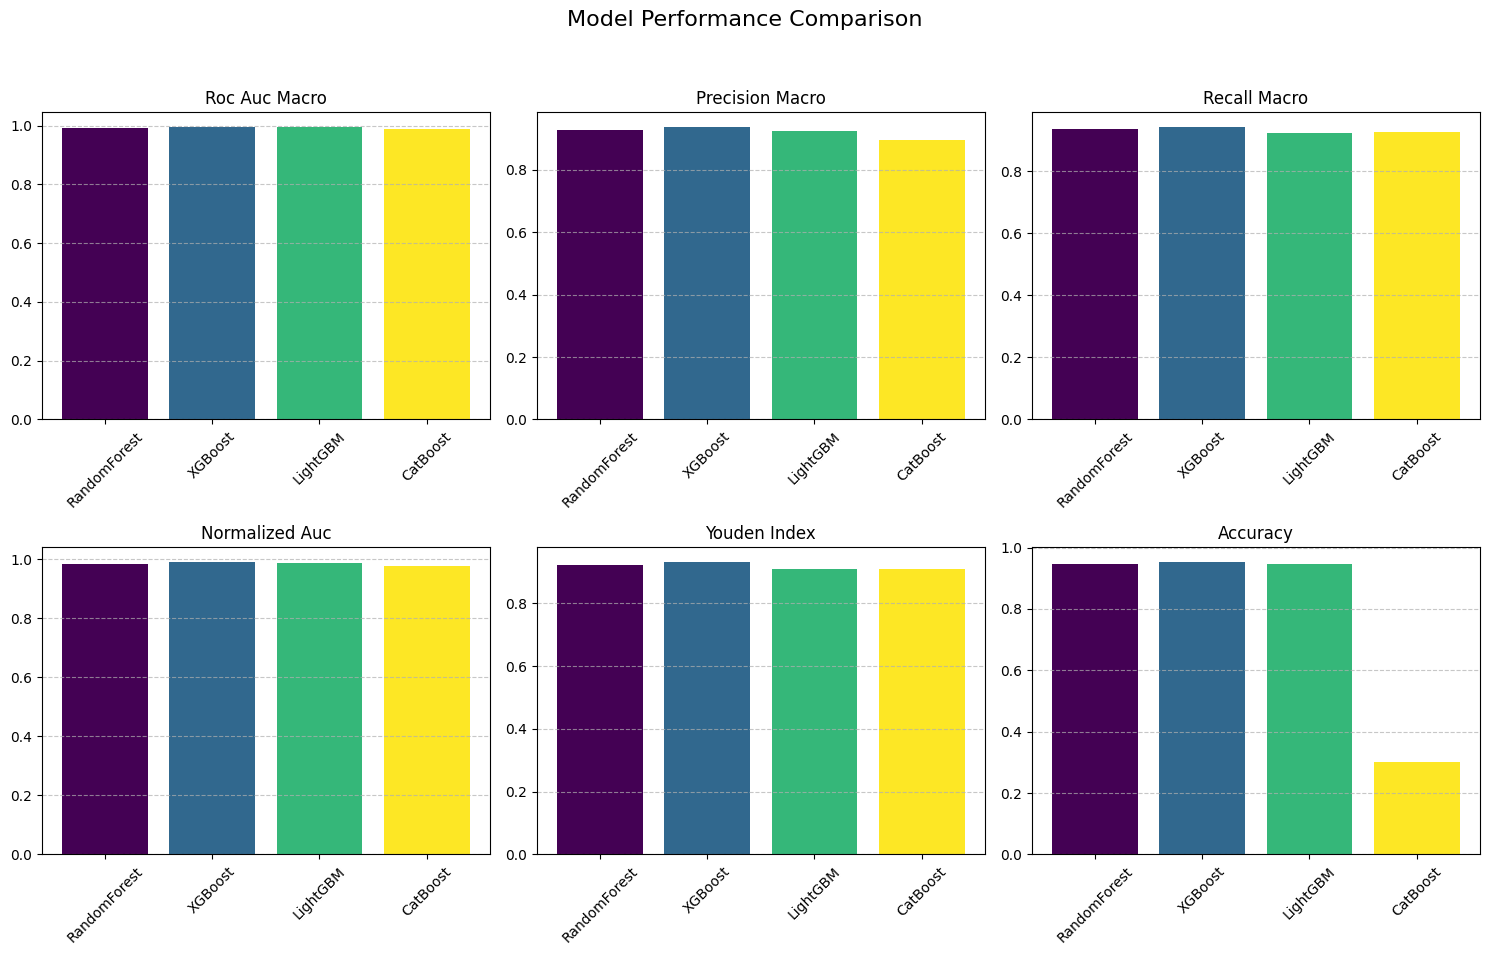

In [10]:
class MultiClassPredictiveMaintenanceEvaluator:
    """
    Comprehensive evaluator for multi-class predictive maintenance models.
    """

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.results = {}

    def prepare_data(self, df, test_size=0.2, target_col='target', excluded_column = ['datetime', 'failure', 'target']):
        """
        Prepare and split data, ensuring temporal sequence and correct data formats.
        """
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.sort_values(by='datetime').reset_index(drop=True)

        # exclude_cols = ['datetime', 'failure', 'target']
        exclude_cols = excluded_column
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        X = df[feature_cols].fillna(0)
        y = df[target_col]

        split_index = int(len(df) * (1 - test_size))
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

        # Convert y_train and y_test to 1D NumPy arrays to ensure compatibility
        y_train = y_train.values
        y_test = y_test.values

        print(f"Dataset shape: {df.shape}")
        print(f"Feature columns: {len(feature_cols)}")
        print(f"\nTrain set shape: {X_train.shape}")
        print(f"Test set shape: {X_test.shape}\n")

        return X_train, X_test, y_train, y_test

    def initialize_models(self):
        """
        Initialize all machine learning models.
        """
        self.models = {
            'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=self.random_state, n_jobs=-1),
            'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, eval_metric='mlogloss'),
            'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=100, depth=8, learning_rate=0.03,l2_leaf_reg=5, auto_class_weights="Balanced" ,random_seed=self.random_state, verbose=100)
        }

    def calculate_metrics(self, y_true, y_pred, y_pred_proba):
        """
        Calculate comprehensive metrics for multi-class classification.
        """
        metrics = {}
        classes = np.unique(y_true)
        
        # 1. ROC AUC (macro and micro)
        metrics['ROC_AUC_macro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
        metrics['ROC_AUC_micro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='micro')

        # 2. Normalized AUC
        per_class_aucs = [roc_auc_score(y_true == c, y_pred_proba[:, i]) for i, c in enumerate(classes)]
        metrics['Normalized_AUC'] = np.mean([(auc - 0.5) / 0.5 for auc in per_class_aucs])

        # 3. Youden Index
        youden_scores = []
        for i, c in enumerate(classes):
            y_true_binary = (y_true == c)
            y_pred_binary = (y_pred == c)
            tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden_scores.append(sensitivity + specificity - 1)
        metrics['Youden_Index'] = np.mean(youden_scores)
        
        # 4. Precision (macro and micro)
        metrics['Precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Precision_micro'] = precision_score(y_true, y_pred, average='micro', zero_division=0)

        # 5. Recall (macro and micro)
        metrics['Recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Recall_micro'] = recall_score(y_true, y_pred, average='micro', zero_division=0)
        
        metrics['Accuracy'] = np.mean(y_true == y_pred)
        return metrics

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        """
        Train all models and evaluate their performance.
        """
        X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_train.columns]
        X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_test.columns]

        self.initialize_models()
        self.results = {}

        for model_name, model in self.models.items():
            print(f"Training {model_name}...")
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
            metrics = self.calculate_metrics(y_test, y_pred, y_pred_proba)

            self.results[model_name] = {'metrics': metrics, 'y_pred': y_pred}
            print(f"{model_name} - ROC AUC (macro): {metrics['ROC_AUC_macro']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")

    def print_detailed_results(self, y_test):
        """
        Print detailed classification reports and confusion matrices.
        """
        print("\n" + "="*80 + "\nDETAILED EVALUATION RESULTS\n" + "="*80)
        summary_data = [{'Model': name, **{k: f"{v:.4f}" for k, v in res['metrics'].items()}}
                        for name, res in self.results.items()]
        
        print("\nSUMMARY OF ALL METRICS:")
        print(pd.DataFrame(summary_data).to_string(index=False))

        for model_name, result in self.results.items():
            print(f"\n{'-'*60}\nDETAILED RESULTS FOR {model_name}\n{'-'*60}")
            print("Classification Report:\n", classification_report(y_test, result['y_pred']))
            print("Confusion Matrix:\n", confusion_matrix(y_test, result['y_pred']))

    def plot_results(self, figsize=(15, 10)):
        """
        Create and display visualizations of model performance.
        """
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Model Performance Comparison', fontsize=16)
        axes = axes.ravel()
        
        metrics_to_plot = ['ROC_AUC_macro', 'Precision_macro', 'Recall_macro', 'Normalized_AUC', 'Youden_Index', 'Accuracy']
        model_names = list(self.results.keys())

        for i, metric in enumerate(metrics_to_plot):
            ax = axes[i]
            scores = [self.results[model]['metrics'][metric] for model in model_names]
            ax.bar(model_names, scores, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
            ax.set_title(metric.replace('_', ' ').title())
            ax.tick_params(axis='x', labelrotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()



excluded_columns = ['datetime', 'failure', 'target'] 


def run_complete_evaluation(df):
    """
    Run the complete evaluation pipeline.
    """
    evaluator = MultiClassPredictiveMaintenanceEvaluator(random_state=42)
    X_train, X_test, y_train, y_test = evaluator.prepare_data(df=df, excluded_column = excluded_columns)
    evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    evaluator.print_detailed_results(y_test)
    evaluator.plot_results()
    return evaluator, X_test, y_test

# --- Main Execution ---
# df = pd.read_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")
evaluator_results, X_test, y_test = run_complete_evaluation(df)

<br> <br>

CatBoost accuracy is much lower than other ML models because of one or more of the following reasons:

- **Class imbalance handling:** CatBoost may not be configured with the correct class weights or balancing strategy for your multi-class, imbalanced dataset. The other models (RandomForest, LightGBM, XGBoost) have explicit parameters for class weighting (`class_weight`, `scale_pos_weight`, etc.), but CatBoost requires `class_weights` or `auto_class_weights='Balanced'` for proper balancing.
- **Hyperparameter settings:** The default hyperparameters for CatBoost (e.g., `iterations`, `depth`, `learning_rate`) may not be optimal for your data, while the other models might be better tuned.
- **Feature preprocessing:** CatBoost handles categorical features natively, but if your features are already encoded or not properly specified, it may not leverage its strengths.
- **Random seed or data split:** If the random seed or train/test split is not consistent, CatBoost may be affected more due to its internal handling of randomness.
- **Implementation bug:** There could be a bug in how CatBoost is initialized or trained in your pipeline. For example, if the target labels are not correctly mapped or if the training data is not properly shuffled.

To improve CatBoost accuracy, check:
- That you set `auto_class_weights='Balanced'` or provide explicit `class_weights` for imbalanced data.
- That your target labels are correctly mapped and encoded.
- That you tune CatBoost hyperparameters.
- That you use the same train/test split and preprocessing for all models.

You can review the CatBoost initialization in your code at `MultiClassPredictiveMaintenanceEvaluator` for possible improvements.

In [11]:
# Save each model as a .pkl file

model_save_path = "../../model/azure_pm/balanced_model/"

for model_name, model in evaluator_results.models.items():
    with open(f"{model_save_path}{model_name}.pkl", "wb") as f:
          pickle.dump(model, f)          

<br> <br>

---

<br> <br> <br>


# Causality

In [12]:
def create_causal_network(df, features, regularize=True, noise_level=1e-4):
    X_selected = df[features].values

    # Initialize the VARLiNGAM model
    model = lingam.VARLiNGAM()

    # Attempt to fit the model; add noise if a LinAlgError occurs
    try:
        model.fit(X_selected)
    except np.linalg.LinAlgError as e:
        print("LinAlgError encountered during model fitting:", e)
        if regularize:
            print(f"Applying regularization: adding noise (std={noise_level}) to the data and trying again.")
            X_selected += np.random.normal(0, noise_level, X_selected.shape)
            model.fit(X_selected)
        else:
            raise e

    # Retrieve the adjacency matrices (one per lag)
    adjacency_matrices = model.adjacency_matrices_

    # Build a directed graph and create a list of dictionaries for each non-zero edge.
    G = nx.DiGraph()
    G.add_nodes_from(features)
    n_features = len(features)
    structured_adjacency = []

    # Loop through each adjacency matrix (one per lag)
    for lag_index, adj_matrix in enumerate(adjacency_matrices):
        for i in range(n_features):
            for j in range(n_features):
                weight = adj_matrix[i, j]
                if weight != 0:
                    edge_dict = {
                        "source_feature": features[i],
                        "target_feature": features[j],
                        "effect_strength": weight,
                    }
                    structured_adjacency.append(edge_dict)
                    G.add_edge(features[i], features[j], weight=weight)

    # Plot the graph using a spring layout for clarity
    pos = nx.spring_layout(G, seed=42)  # seed for reproducibility
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=1500,
        arrowstyle="->",
        arrowsize=20,
        edge_color="gray",
        font_size=10,
        ax=ax,
    )

    # Display the edge weights formatted to two decimal places
    edge_labels = nx.get_edge_attributes(G, "weight")
    edge_labels = {edge: f"{weight:.2f}" for edge, weight in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", ax=ax)

    ax.set_title("Causal Network Graph from VARLiNGAM")
    ax.axis("off")
    # plt.show()
    plt.close()

    return structured_adjacency, fig


In [13]:
cols_without_datetime_failure = [col for col in df.columns if "datetime" not in col and "failure" not in col]


structured_adjacency, fig = create_causal_network(df=df, features=cols_without_datetime_failure)

---

<br> <br> 

# Generate top-n rows using SHAP

#### Read ML models

In [14]:
model_dir = f"../../model/azure_pm/balanced_model/"
pkl_files = glob.glob(os.path.join(model_dir, "*.pkl"))

models = {}
for file_path in pkl_files:
    model_name = os.path.splitext(os.path.basename(file_path))[0]
    with open(file_path, "rb") as f:
        models[model_name] = pickle.load(f)

print(f"Loaded {len(models)} models: {list(models.keys())}")

my_models = {
    "catboost_model": 'CatBoost', 
    "lightgbm_model": 'LightGBM', 
    "randomforest_model": 'RandomForest', 
    "xgboost_model": 'XGBoost'
}

# model = models["XGBoost"]
# model = models[my_models["catboost_model"]]
# model = models[my_models["lightgbm_model"]]
# model = models[my_models["randomforest_model"]]
model = models[my_models["xgboost_model"]]
model



Loaded 4 models: ['CatBoost', 'LightGBM', 'RandomForest', 'XGBoost']


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

<br> <br> <br>

## Find Uncertain Rows

In [15]:
X_test
# y_test

,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
1795,0.582450,0.335698,0.349092,0.501931,0,0,0.402927,0.492563,0.391592,0.494181,...,0.119922,0.352658,0.853637,0.577118,0.142876,0.0,0.0,0.0,0.0,3.0
1796,0.322659,0.536251,0.306256,0.228944,0,0,0.537619,0.273908,0.496331,0.492893,...,0.109239,0.136548,0.548184,0.365364,0.112642,0.0,0.0,0.0,0.0,0.0
1797,0.482847,0.654256,0.491698,0.505463,0,0,0.605658,0.683169,0.368401,0.512103,...,0.116611,0.146254,0.603271,0.463692,0.048858,0.0,0.0,0.0,0.0,0.0
1798,0.661065,0.370569,0.227979,0.621223,0,0,0.663877,0.448162,0.476047,0.479351,...,0.152582,0.094849,0.764135,0.372498,0.191430,0.0,0.0,0.0,0.0,0.0
1799,0.480250,0.326948,0.345257,0.700335,0,0,0.581277,0.614477,0.370262,0.566089,...,0.097755,0.292391,0.700335,0.454587,0.130542,0.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,0.863064,0.542359,0.559759,0.294727,0,0,0.718156,0.359705,0.688871,0.447670,...,0.126247,0.203251,0.664941,0.406241,0.069283,0.0,0.0,0.0,0.0,1.0
2240,0.813549,0.652503,0.789897,0.700831,0,0,0.574782,0.461880,0.600941,0.421987,...,0.157192,0.482895,0.960479,0.596342,0.072981,0.0,0.0,0.0,0.0,5.0
2241,0.620622,0.515321,0.275955,0.411961,0,0,0.776013,0.676765,0.814145,0.339036,...,0.099582,0.260616,0.617613,0.414530,0.099916,0.0,0.0,0.0,0.0,1.0
2242,0.863064,0.542359,0.559759,0.294727,0,0,0.718156,0.359705,0.688871,0.447670,...,0.126247,0.203251,0.664941,0.406241,0.069283,0.0,0.0,0.0,0.0,1.0


In [16]:
def get_uncertain_rows(X_test, y_test, model, uncertainty_threshold=0.6):
    """
    Returns rows from X_test where the model's prediction confidence is below the uncertainty_threshold
    and the true target is not 0. Also prints the predicted class, its probability, and the true target value for each uncertain row.

    Parameters:
        X_test (pd.DataFrame): Test features.
        y_test (array-like): True labels for X_test.
        model: Trained ML model with predict_proba method.
        uncertainty_threshold (float): Maximum probability threshold for uncertainty.

    Returns:
        pd.DataFrame: Uncertain rows from X_test with their true and predicted labels and probabilities.
    """
    probs = model.predict_proba(X_test)
    max_probs = probs.max(axis=1)
    preds = model.classes_[probs.argmax(axis=1)]
    mask = (max_probs < uncertainty_threshold) & (y_test != 0)

    uncertain_rows = X_test[mask].copy()
    uncertain_rows['true_label'] = y_test[mask]
    uncertain_rows['predicted_label'] = preds[mask]
    uncertain_rows['max_probability'] = max_probs[mask]
    uncertain_rows['all_probabilities'] = list(probs[mask])

    # Print predicted class, probability, and true target value for each uncertain row
    for idx, row in uncertain_rows.iterrows():
        print(
            f"Index: {idx}, Predicted class: {row['predicted_label']}, "
            f"Probability: {row['max_probability']:.4f}, True target value: {row['true_label']}"
        )

    return uncertain_rows

# Example usage:
uncertain_rows = get_uncertain_rows(X_test=X_test, y_test=y_test, model=model, uncertainty_threshold=0.6)
display(uncertain_rows)



Index: 1799, Predicted class: 2, Probability: 0.5423, True target value: 2
Index: 1802, Predicted class: 2, Probability: 0.5423, True target value: 2
Index: 1836, Predicted class: 1, Probability: 0.5083, True target value: 2
Index: 1868, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 1869, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 1871, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 1872, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 2147, Predicted class: 3, Probability: 0.5117, True target value: 4
Index: 2201, Predicted class: 2, Probability: 0.4927, True target value: 1
Index: 2202, Predicted class: 2, Probability: 0.4927, True target value: 1
Index: 2203, Predicted class: 2, Probability: 0.4927, True target value: 1
Index: 2204, Predicted class: 2, Probability: 0.4927, True target value: 1


,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h,true_label,predicted_label,max_probability,all_probabilities
1799,0.480250,0.326948,0.345257,0.700335,0,0,0.581277,0.614477,0.370262,0.566089,...,0.130542,0.0,0.0,0.0,0.0,3.0,2,2,0.542266,"[0.00502974, 0.45018107, 0.542266, 0.000990668..."
1802,0.480250,0.326948,0.345257,0.700335,0,0,0.581277,0.614477,0.370262,0.566089,...,0.130542,0.0,0.0,0.0,0.0,3.0,2,2,0.542266,"[0.00502974, 0.45018107, 0.542266, 0.000990668..."
1836,0.534959,0.498984,0.387318,0.306257,0,0,0.553272,0.534124,0.456673,0.443091,...,0.119209,0.0,0.0,0.0,0.0,3.0,2,1,0.508276,"[0.033296786, 0.5082761, 0.45402017, 0.0023580..."
1868,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
1869,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
1871,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
1872,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
2147,0.523501,0.304201,0.554969,0.485445,0,0,0.520893,0.564236,0.573141,0.455696,...,0.143475,0.0,0.0,0.0,0.0,5.0,4,3,0.511723,"[0.00011257414, 7.383208e-05, 0.41766262, 0.51..."
2201,0.535242,0.204390,0.579790,0.274766,0,0,0.614190,0.664256,0.350340,0.545567,...,0.110868,0.0,0.0,0.0,0.0,3.0,1,2,0.492746,"[0.018439405, 0.48220786, 0.49274576, 0.003500..."
2202,0.535242,0.204390,0.579790,0.274766,0,0,0.614190,0.664256,0.350340,0.545567,...,0.110868,0.0,0.0,0.0,0.0,3.0,1,2,0.492746,"[0.018439405, 0.48220786, 0.49274576, 0.003500..."


In [17]:
row_number = 1836


random_row = X_test.loc[row_number].to_frame().T
random_row_target_label = uncertain_rows.loc[row_number]["true_label"]
print(f"The true label is: {uncertain_rows.loc[row_number]['true_label']}, and the model predicted {uncertain_rows.loc[row_number]['predicted_label']}")

display(random_row)

# random_row.drop(columns=["comp_lag_12h"], inplace=True)

The true label is: 2, and the model predicted 1


,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
1836,0.534959,0.498984,0.387318,0.306257,0.0,0.0,0.553272,0.534124,0.456673,0.443091,...,0.108715,0.220765,0.611158,0.357061,0.119209,0.0,0.0,0.0,0.0,3.0


<br> <br> 

## Generate top-n rows using SHAP

,feature_name,feature_importance
0,error_count_24h,0.988052
1,volt_std_6h,0.232838
2,volt_max_24h,0.193280
3,comp,0.163973
4,rotate,0.150951
5,vibration_std_6h,0.098294
6,rotate_lag_24h,0.079407
7,volt_mean_6h,0.074056
8,rotate_lag_6h,0.070109
9,vibration_lag_1h,0.068490


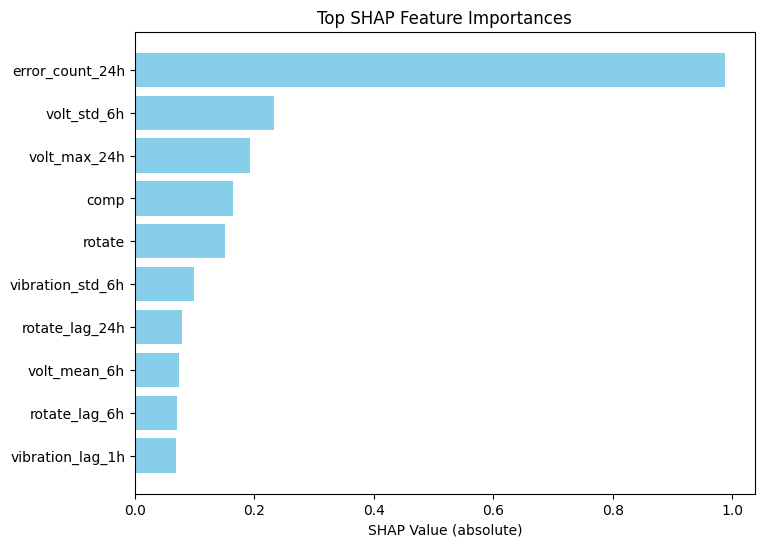

In [18]:
def get_top_n_shap_features(random_row, model, top_n=10):
    feature_names = model.feature_names_in_
    X_row = random_row
    X_row = X_row.apply(pd.to_numeric, errors='coerce')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = pd.DataFrame({
        'feature_name': feature_names[:min_len],
        'feature_importance': shap_abs[:min_len]
    }).sort_values('feature_importance', ascending=False).head(top_n).reset_index(drop=True)

    return df_shap


df_shap = get_top_n_shap_features(random_row=random_row, model=model, top_n=10)
display(df_shap)


# Visualize SHAP values from df_shap as a horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(df_shap['feature_name'][::-1], df_shap['feature_importance'][::-1], color='skyblue')
plt.xlabel('SHAP Value (absolute)')
plt.title('Top SHAP Feature Importances')
plt.show()

<br> <br>

---

<br> <br> <br>

# Taxonomy  

In [19]:
def format_taxonomy(taxonomy_json):
    """Formats a hierarchical taxonomy into a tree-like string."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON string if needed

    # Build tree structure
    tree = defaultdict(list)
    for feature, (_, parent) in taxonomy_json.items():
        tree[parent].append(feature)

    def display_tree(parent="Root", level=0):
        """Recursively formats the tree structure with icons and connectors."""
        if parent not in tree:
            return ""

        result = ""
        for idx, child in enumerate(tree[parent]):
            is_parent = child in tree  # Check if child has further children
            icon = "📂" if is_parent else "📄"  # Folder for parents, file for leaf nodes
            connector = "└── " if idx == len(tree[parent]) - 1 else "├── "  # Tree connectors
            result += "  " * level + connector + f"{icon} {child}\n"
            result += display_tree(child, level + 1)  # Recursive call for children

        return result

    return f"\n📌 **Taxonomy Structure:**\n\n{display_tree('Root')}".strip()

def get_taxonomy_paths(taxonomy_json, node_names):
    """Returns hierarchical paths for given nodes in a taxonomy."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON if it's a string

    # Reverse lookup: Map each child to its parent
    child_to_parent = {child: parent for child, (_, parent) in taxonomy_json.items()}

    def get_path(node):
        """Recursively constructs the hierarchy path for a node."""
        path = [node]
        while node in child_to_parent and child_to_parent[node] != "Root":
            node = child_to_parent[node]
            path.append(node)
        return " --> ".join(reversed(path))  # Reverse to get correct hierarchy order
    return {node: get_path(node) for node in node_names}


with open('../../taxonomy/deepseek.json', 'r') as file:
    deepseek_taxonomy = json.load(file)

with open('../../taxonomy/gemma2.json', 'r') as file:
    gemma2_taxonomy = json.load(file)

with open('../../taxonomy/llama3.json', 'r') as file:
    llama3_taxonomy = json.load(file)

with open('../../taxonomy/gpt4o.json', 'r') as file:
    gpt4o_taxonomy = json.load(file)

with open('../../taxonomy/gpt4o_edited.json', 'r') as file:
    gpt4o_edited_taxonomy = json.load(file)    

In [20]:
print(format_taxonomy(gpt4o_edited_taxonomy))

📌 **Taxonomy Structure:**

├── 📂 datetime
  ├── 📄 hour
  ├── 📄 day_of_week
  ├── 📄 is_weekend
  └── 📄 is_working_hours
├── 📂 volt
  ├── 📄 volt_lag_1h
  ├── 📄 volt_lag_6h
  ├── 📄 volt_lag_12h
  ├── 📄 volt_lag_24h
  ├── 📄 volt_mean_24h
  ├── 📄 volt_std_24h
  ├── 📄 volt_min_24h
  ├── 📄 volt_max_24h
  ├── 📄 volt_mean_6h
  └── 📄 volt_std_6h
├── 📂 rotate
  ├── 📄 rotate_lag_1h
  ├── 📄 rotate_lag_6h
  ├── 📄 rotate_lag_12h
  ├── 📄 rotate_lag_24h
  ├── 📄 rotate_mean_24h
  ├── 📄 rotate_std_24h
  ├── 📄 rotate_min_24h
  ├── 📄 rotate_max_24h
  ├── 📄 rotate_mean_6h
  └── 📄 rotate_std_6h
├── 📂 pressure
  ├── 📄 pressure_lag_1h
  ├── 📄 pressure_lag_6h
  ├── 📄 pressure_lag_12h
  ├── 📄 pressure_lag_24h
  ├── 📄 pressure_mean_24h
  ├── 📄 pressure_std_24h
  ├── 📄 pressure_min_24h
  ├── 📄 pressure_max_24h
  ├── 📄 pressure_mean_6h
  └── 📄 pressure_std_6h
├── 📂 vibration
  ├── 📄 vibration_lag_1h
  ├── 📄 vibration_lag_6h
  ├── 📄 vibration_lag_12h
  ├── 📄 vibration_lag_24h
  ├── 📄 vibration_mean_24h
  ├── 📄 vibra

<br> <br>

#### See the hierarchy

In [21]:
# Test the function with the openai_taxonomy data

shap_features = {
    'feature': df_shap["feature_name"].to_list()
}
features_to_find = shap_features["feature"]

taxonomy_model = [gpt4o_taxonomy, llama3_taxonomy, gemma2_taxonomy, deepseek_taxonomy, gpt4o_edited_taxonomy, ]
index = 4

match index:
    case 0:
        print("GPT-4o")
    case 1:
        print("Llama 3.3")
    case 2:
        print("Gemma2")
    case 3:
        print("DeepSeek")
    case 4:
        print("GPT-4o Edited")
    case _:
        print("Unknown model")

try:
    # Get paths for all selected features
    feature_paths = get_taxonomy_paths(taxonomy_model[index], features_to_find)

    # Print the results in a formatted way, removing "Sensor_Reading --> " from the start
    print("\n=== Taxonomy Paths ===\n")
    for feature, path in feature_paths.items():
        if path.startswith("Sensor_Readings --> "):
            path = path[len("Sensor_Readings --> "):]
        print(f"{path}")
except IndexError as e:
    print("Taxonomy model index is out of reach")

GPT-4o Edited

=== Taxonomy Paths ===

errorID --> error_count_24h
volt --> volt_std_6h
volt --> volt_max_24h
comp
rotate
vibration --> vibration_std_6h
rotate --> rotate_lag_24h
volt --> volt_mean_6h
rotate --> rotate_lag_6h
vibration --> vibration_lag_1h


<br> <br>

---

<br> <br> <br>

## Visualize The subgraph - Advanced Visualization - Target included


In [22]:
def create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph.html", width="100%", height="1000px"):
    """
    Creates an interactive HTML visualization of the causal graph containing top SHAP features.
    
    This version includes the top_n_sub_nodes filtering logic and creates an interactive visualization
    using pyvis instead of matplotlib.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column identifying the core features.
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 
                                     and 'effect_strength' keys.
        top_n_sub_nodes (int, optional): The number of top related nodes to include in the graph,
                                         ranked by absolute effect_strength. If None, all directly
                                         connected nodes are included. Defaults to None.
        filename (str): The name of the output HTML file. Defaults to "interactive_causal_graph.html".
        width (str): Width of the visualization. Defaults to "100%".
        height (str): Height of the visualization. Defaults to "1000px".
    
    Returns:
        str: JSON string of the subgraph (same as original function).
    """
    import networkx as nx
    import json
    import pandas as pd
    from pyvis.network import Network

    top_features = set(df_shap["feature_name"])
    target_variable = 'target'  # Define the target variable name
    
    # Store original effect strengths for JSON output
    edge_strengths = {}
    
    # If top_n_sub_nodes is specified, filter to the most influential relationships
    if top_n_sub_nodes is not None and isinstance(top_n_sub_nodes, int) and top_n_sub_nodes >= 0:
        # 1. Find all edges connecting top_features to other nodes (sub-nodes), excluding target
        relevant_edges = []
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            strength = abs(edge.get("effect_strength", 0))  # Use absolute strength for ranking
            
            # Find relationships where one node is in top_features and the other is not (excluding target variable)
            if source in top_features and target not in top_features and target != target_variable:
                relevant_edges.append({
                    'top_feature': source,
                    'sub_node': target,
                    'strength': strength,
                    'original_edge': edge
                })
            elif target in top_features and source not in top_features and source != target_variable:
                relevant_edges.append({
                    'top_feature': target,
                    'sub_node': source,
                    'strength': strength,
                    'original_edge': edge
                })
        
        # 2. Sort all relationships by effect strength and select top N
        sorted_relationships = sorted(relevant_edges, key=lambda x: x['strength'], reverse=True)
        top_relationships = sorted_relationships[:top_n_sub_nodes]
        
        # 3. Get the set of sub-nodes from top N relationships
        top_sub_nodes_set = {rel['sub_node'] for rel in top_relationships}
        
        print(f"Selected top {len(top_relationships)} relationships with sub-nodes: {top_sub_nodes_set}")
        for i, rel in enumerate(top_relationships, 1):
            print(f"  {i}. {rel['top_feature']} ↔ {rel['sub_node']} (strength: {rel['strength']:.4f})")
        
        # 4. The final set of nodes includes top features, selected sub-nodes, AND target variable
        allowed_nodes = top_features.union(top_sub_nodes_set).union({target_variable})
        
        # 5. Filter edges where both source and target are in our allowed set
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            if source in allowed_nodes and target in allowed_nodes:
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
    else:
        # Original logic: include all nodes directly connected to any top_feature, PLUS target variable
        sub_edges = []
        edge_labels = {}
        allowed_nodes = set()
        
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            # Include edges connected to top_features OR target variable
            if (source in top_features) or (target in top_features) or (source == target_variable) or (target == target_variable):
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
                allowed_nodes.add(source)
                allowed_nodes.add(target)

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_edges_from(sub_edges)
    
    # Add edge labels as attributes to the graph
    for (u, v), label in edge_labels.items():
        if G.has_edge(u, v):
            G.edges[u, v]['label'] = label

    # If the graph is empty, return an empty JSON and skip visualization
    if not G.nodes():
        print("Warning: The resulting graph is empty. No relationships found based on the criteria.")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Create interactive visualization using pyvis
    print(f"Creating interactive visualization with {len(G.nodes())} nodes and {len(G.edges())} edges...")
    
    net = Network(height=height, width=width, notebook=False, directed=True, cdn_resources='in_line')

    # Set physics options for better layout and interactivity
    net.set_options("""
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": { 
          "centralGravity": 0.2, 
          "springLength": 200, 
          "nodeDistance": 300,
          "damping": 0.1
        },
        "minVelocity": 0.75,
        "solver": "repulsion",
        "timestep": 0.22,
        "stabilization": {"iterations": 150}
      },
      "edges": {
        "arrows": {
          "to": {"enabled": true, "scaleFactor": 1.5}
        },
        "smooth": {
          "enabled": true,
          "type": "continuous"
        }
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "selectConnectedEdges": true,
        "hover": true,
        "multiselect": true,
        "keyboard": {
          "enabled": true
        }
      },
      "manipulation": {
        "enabled": false
      }
    }
    """)

    # Add nodes to the pyvis network with enhanced interactivity
    for node in G.nodes():
        is_top = node in top_features
        is_target = node == target_variable  
        
        # Determine node styling based on type
        if is_target:
            color = 'red'
            node_type = '🎯 TARGET VARIABLE'
            size = 35  # Larger size for target
        elif is_top:
            color = 'orange'
            node_type = '⭐ Top SHAP Feature'
            size = 25
        else:
            color = 'skyblue'
            node_type = '🔗 Related Feature'
            size = 20
            
        net.add_node(
            node, 
            label=node, 
            color=color,
            shape='box', 
            shadow=True, 
            font={'size': 18, 'color': 'black', 'strokeWidth': 2, 'strokeColor': 'white'},
            size=size,
            borderWidth=3 if is_target else 2,
            borderWidthSelected=5 if is_target else 4,
            title=f"{node_type}: {node}<br/>Click and drag to move!"  # Enhanced tooltip
        )

    # Add edges to the pyvis network with enhanced styling
    for u, v in G.edges():
        label = G.edges[u, v].get('label', '')
        is_highlight = (u in top_features and v in top_features)
        is_target_edge = (u == target_variable or v == target_variable)
        
        # Special styling for edges connected to target
        if is_target_edge:
            edge_color = 'darkred'
            edge_width = 5
            edge_title = f"🎯 TARGET CONNECTION - Effect strength: {label}<br/>From: {u} → To: {v}"
        elif is_highlight:
            edge_color = 'red'
            edge_width = 4
            edge_title = f"📊 SHAP-SHAP Connection - Effect strength: {label}<br/>From: {u} → To: {v}"
        else:
            edge_color = 'gray'
            edge_width = 2
            edge_title = f"📊 Effect strength: {label}<br/>From: {u} → To: {v}"
            
        net.add_edge(
            u, v, 
            label=label, 
            color=edge_color,
            width=edge_width,
            title=edge_title,  # Enhanced tooltip
            font={'size': 12, 'color': 'blue', 'strokeWidth': 1, 'strokeColor': 'white'}
        )

    # Generate and save HTML content with proper encoding
    html_content = net.generate_html()
    try:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"[SUCCESS] Interactive graph saved to '{filename}'. Open this file in your browser.")
    except Exception as e:
        print(f"[ERROR] Could not save the HTML file. Reason: {e}")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Generate JSON output (same as original function, but include target info)
    subgraph_json = {
        "nodes": [
            {
                "id": node, 
                "highlight": node in top_features,
                "is_target": node == target_variable,
                "node_type": "target" if node == target_variable else ("shap_feature" if node in top_features else "related_feature")
            }
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features),
                "is_target_connection": (u == target_variable or v == target_variable),
                "effect_strength": edge_strengths.get((u, v), 0.0)  # Use original numeric value
            }
            for u, v in G.edges()
        ]
    }
    
    return json.dumps(subgraph_json, indent=2)

In [23]:
# Example usage with custom size:
# For a larger plot:
# result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=7, filename="large_graph.html", width="1400px", height="1200px")
# 
# For full screen:
result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph_with_target.html", width="100vw", height="100vh")

Creating interactive visualization with 36 nodes and 69 edges...
[SUCCESS] Interactive graph saved to 'interactive_causal_graph_with_target.html'. Open this file in your browser.


In [24]:
df_shap

,feature_name,feature_importance
0,error_count_24h,0.988052
1,volt_std_6h,0.232838
2,volt_max_24h,0.193280
3,comp,0.163973
4,rotate,0.150951
5,vibration_std_6h,0.098294
6,rotate_lag_24h,0.079407
7,volt_mean_6h,0.074056
8,rotate_lag_6h,0.070109
9,vibration_lag_1h,0.068490


<br> <br> <br>

---

<br> <br> <br>

# Counterfactual

<br>

Looking at the `run_advanced_counterfactuals()` function, I can see it's designed to generate counterfactual examples by perturbing top SHAP features and analyzing how model predictions change. 




In [ ]:
# def run_advanced_counterfactuals(
#     df_shap,
#     structured_adjacency,
#     base_row,
#     model_dict,
#     num_runs=10,
#     perturbation_scale=0.1,
#     perturbation_method='gaussian',  # 'gaussian', 'uniform', or 'fixed'
#     fixed_value=None,                # Used if method is 'fixed'
#     random_seed=None,
#     verbose=True
# ):
#     """
#     Advanced counterfactual generator for SHAP-causal subgraph with improved error handling.
#     Tracks feature changes, supports multiple perturbation methods, and logs model predictions.

#     Args:
#         df_shap (pd.DataFrame): Top SHAP features DataFrame.
#         structured_adjacency (list): Causal graph adjacency list.
#         base_row (pd.DataFrame or pd.Series): The base row to perturb.
#         model_dict (dict): Model dictionary with 'model' and 'feature_names'.
#         num_runs (int): Number of counterfactual runs.
#         perturbation_scale (float): Scale of random perturbation for features.
#         perturbation_method (str): 'gaussian', 'uniform', or 'fixed'.
#         fixed_value (float): Value to set if method is 'fixed'.
#         random_seed (int or None): Random seed for reproducibility.
#         verbose (bool): If True, print detailed logs.

#     Returns:
#         consistent_nodes (dict): Nodes with consistent values and their value.
#         cf_df (pd.DataFrame): All counterfactual results for inspection.
#         logs (list): List of dicts with feature changes and predictions for each run.
#     """
#     import numpy as np
#     import pandas as pd

#     try:
#         if random_seed is not None:
#             np.random.seed(random_seed)

#         # Handle both DataFrame and Series input for base_row
#         if isinstance(base_row, pd.DataFrame):
#             if len(base_row) == 1:
#                 base_row = base_row.iloc[0]  # Convert single-row DataFrame to Series
#             else:
#                 raise ValueError("base_row DataFrame must contain exactly one row")
#         elif not isinstance(base_row, pd.Series):
#             raise ValueError("base_row must be a pandas Series or single-row DataFrame")

#         # Validate inputs
#         if df_shap.empty:
#             raise ValueError("df_shap DataFrame is empty")
        
#         if 'feature_name' not in df_shap.columns:
#             raise ValueError("df_shap must have 'feature_name' column")

#         # Get the subgraph nodes (features) from the SHAP-causal mapping
#         top_features = set(df_shap['feature_name'])
#         subgraph_nodes = set()
        
#         for edge in structured_adjacency:
#             if (edge['source_feature'] in top_features) or (edge['target_feature'] in top_features):
#                 subgraph_nodes.add(edge['source_feature'])
#                 subgraph_nodes.add(edge['target_feature'])
        
#         # Filter to only include nodes that exist in base_row
#         subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]
        
#         if not subgraph_nodes:
#             if verbose:
#                 print("Warning: No subgraph nodes found in base_row. Using top_features only.")
#             subgraph_nodes = [f for f in top_features if f in base_row.index]
        
#         if not subgraph_nodes:
#             raise ValueError("No valid features found in base_row that match SHAP features")

#         base_values = base_row[subgraph_nodes].copy()
#         model = model_dict['model']
#         feature_names = model_dict['feature_names']

#         # Validate that all required features are present
#         missing_features = [f for f in feature_names if f not in base_row.index]
#         if missing_features and verbose:
#             print(f"Warning: Missing features in base_row: {missing_features}")

#         counterfactual_results = []
#         logs = []
#         successful_runs = 0

#         for i in range(num_runs):
#             try:
#                 perturbed = base_values.copy()
#                 feature_changes = []
                
#                 if verbose:
#                     print(f"\nCounterfactual run {i+1}:")
                
#                 # Perturb only top features that exist in the data
#                 for feat in top_features:
#                     if feat in perturbed.index:
#                         old_value = perturbed[feat]
                        
#                         # Choose perturbation method
#                         if perturbation_method == 'gaussian':
#                             # Get standard deviation, with fallback
#                             feat_importance = df_shap[df_shap['feature_name'] == feat]['feature_importance']
#                             if not feat_importance.empty:
#                                 std = np.std(feat_importance)
#                                 std = std if std > 0 else 0.05
#                             else:
#                                 std = 0.05
#                             noise = np.random.normal(0, perturbation_scale * std)
#                             new_value = old_value + noise
                            
#                         elif perturbation_method == 'uniform':
#                             noise = np.random.uniform(-perturbation_scale, perturbation_scale)
#                             new_value = old_value + noise
                            
#                         elif perturbation_method == 'fixed':
#                             new_value = fixed_value if fixed_value is not None else old_value
#                             noise = new_value - old_value
                            
#                         else:
#                             raise ValueError(f"Unknown perturbation_method: {perturbation_method}")
                        
#                         perturbed[feat] = new_value
#                         feature_changes.append({
#                             'feature': feat,
#                             'old_value': old_value,
#                             'new_value': new_value,
#                             'perturbation': noise
#                         })
                        
#                         if verbose:
#                             print(f"  Changed feature '{feat}': {old_value:.6f} -> {new_value:.6f} (Δ={noise:.6f})")

#                 # Prepare input for model prediction
#                 full_input = base_row.copy()
#                 for feat in perturbed.index:
#                     full_input[feat] = perturbed[feat]
                
#                 # Ensure we have all required features for the model
#                 model_input = {}
#                 for feat in feature_names:
#                     if feat in full_input.index:
#                         model_input[feat] = full_input[feat]
#                     else:
#                         # Use zero or mean imputation for missing features
#                         model_input[feat] = 0.0
#                         if verbose:
#                             print(f"  Warning: Missing feature '{feat}', using default value 0.0")

#                 X_input = pd.DataFrame([model_input])
#                 X_input = X_input.apply(pd.to_numeric, errors='coerce').fillna(0)
                
#                 # Make prediction
#                 try:
#                     y_pred = model.predict(X_input)[0]
#                     successful_runs += 1
#                 except Exception as pred_error:
#                     if verbose:
#                         print(f"  Prediction error in run {i+1}: {pred_error}")
#                     y_pred = None

#                 counterfactual_results.append(perturbed)
#                 logs.append({
#                     'run': i+1,
#                     'feature_changes': feature_changes,
#                     'model_prediction': y_pred,
#                     'success': y_pred is not None
#                 })

#             except Exception as run_error:
#                 if verbose:
#                     print(f"  Error in run {i+1}: {run_error}")
#                 logs.append({
#                     'run': i+1,
#                     'feature_changes': [],
#                     'model_prediction': None,
#                     'success': False,
#                     'error': str(run_error)
#                 })

#         # Create results DataFrame
#         if counterfactual_results:
#             cf_df = pd.DataFrame(counterfactual_results)
#         else:
#             cf_df = pd.DataFrame()

#         # Find consistent nodes: nodes whose value is (almost) the same across all runs
#         consistent_nodes = {}
#         if not cf_df.empty:
#             for col in cf_df.columns:
#                 values = cf_df[col].values
#                 if len(values) > 1 and np.allclose(values, values[0], atol=1e-4):
#                     consistent_nodes[col] = values[0]
#                 elif len(values) == 1:
#                     consistent_nodes[col] = values[0]

#         if verbose:
#             print(f"\nCompleted {successful_runs}/{num_runs} successful counterfactual runs.")
#             print(f"Consistent nodes in the sub-causal graph:")
#             for node, value in consistent_nodes.items():
#                 print(f"  {node}: {value}")

#         # Summary statistics
#         if verbose:
#             print("\n=== Counterfactual Summary ===")
#             for feat in top_features:
#                 changes = [chg for log in logs for chg in log.get('feature_changes', []) if chg['feature'] == feat]
#                 if changes:
#                     avg_perturb = np.mean([abs(chg['perturbation']) for chg in changes])
#                     print(f"Feature '{feat}': changed {len(changes)} times, avg |perturbation|={avg_perturb:.4f}")

#             # Model predictions summary
#             preds = [log['model_prediction'] for log in logs if log['model_prediction'] is not None]
#             if preds:
#                 unique, counts = np.unique(preds, return_counts=True)
#                 print("Model predictions across runs:", dict(zip(unique, counts)))
#             else:
#                 print("No successful model predictions.")

#         return consistent_nodes, cf_df, logs

#     except Exception as e:
#         if verbose:
#             print(f"Critical error in run_advanced_counterfactuals: {e}")
#         return {}, pd.DataFrame(), []


# # Usage example with error-safe row selection:
# def safe_counterfactual_analysis(X_test, y_test, df_shap, structured_adjacency, model, num_runs=100):
#     """
#     Wrapper function to safely run counterfactual analysis with proper row selection.
#     """
#     try:
#         # Safely select a random row from X_test
#         if len(X_test) == 0:
#             raise ValueError("X_test is empty")
        
#         # Use iloc for position-based selection (safer than loc)
#         random_idx = np.random.randint(0, len(X_test))
#         random_row = X_test.iloc[random_idx]
        
#         print(f"Selected row at position {random_idx} (index: {random_row.name})")
        
#         # Run counterfactual analysis
#         consistent_nodes, all_counterfactuals, logs = run_advanced_counterfactuals(
#             df_shap=df_shap,
#             structured_adjacency=structured_adjacency,
#             base_row=random_row,
#             model_dict={
#                 'model': model,
#                 'feature_names': model.feature_names_in_
#             },
#             num_runs=num_runs,
#             perturbation_scale=0.1,
#             perturbation_method='gaussian',
#             random_seed=42,
#             verbose=True
#         )
        
#         return consistent_nodes, all_counterfactuals, logs, random_row
        
#     except Exception as e:
#         print(f"Error in safe_counterfactual_analysis: {e}")
#         return {}, pd.DataFrame(), [], None




<br> <br> 

In [123]:
def run_advanced_counterfactuals(df_shap, structured_adjacency, base_row, model_dict, num_runs=10, perturbation_scale=0.1, 
                                 perturbation_method='gaussian',  # 'gaussian', 'uniform', or 'fixed'
                                 fixed_value=None,                # Used if method is 'fixed'
                                 random_seed=None,
                                 verbose=True):
    """
    Advanced counterfactual generator for SHAP-causal subgraph with improved error handling.
    Tracks feature changes, supports multiple perturbation methods, and logs model predictions.

    Args:
        df_shap (pd.DataFrame): Top SHAP features DataFrame.
        structured_adjacency (list): Causal graph adjacency list.
        base_row (pd.DataFrame or pd.Series): The base row to perturb.
        model_dict (dict): Model dictionary with 'model' and 'feature_names'.
        num_runs (int): Number of counterfactual runs.
        perturbation_scale (float): Scale of random perturbation for features.
        perturbation_method (str): 'gaussian', 'uniform', or 'fixed'.
        fixed_value (float): Value to set if method is 'fixed'.
        random_seed (int or None): Random seed for reproducibility.
        verbose (bool): If True, print detailed logs.

    Returns:
        consistent_nodes (dict): Nodes with consistent values and their value.
        cf_df (pd.DataFrame): All counterfactual results for inspection.
        logs (list): List of dicts with feature changes and predictions for each run.
    """
    import numpy as np
    import pandas as pd

    try:
        if random_seed is not None:
            np.random.seed(random_seed)

        # Handle both DataFrame and Series input for base_row
        if isinstance(base_row, pd.DataFrame):
            if len(base_row) == 1:
                base_row = base_row.iloc[0]  # Convert single-row DataFrame to Series
            else:
                raise ValueError("base_row DataFrame must contain exactly one row")
        elif not isinstance(base_row, pd.Series):
            raise ValueError("base_row must be a pandas Series or single-row DataFrame")

        # Validate inputs
        if df_shap.empty:
            raise ValueError("df_shap DataFrame is empty")
        
        if 'feature_name' not in df_shap.columns:
            raise ValueError("df_shap must have 'feature_name' column")

        # Get the subgraph nodes (features) from the SHAP-causal mapping
        top_features = set(df_shap['feature_name'])
        subgraph_nodes = set()
        
        # Build subgraph including causal relationships
        for edge in structured_adjacency:
            if (edge['source_feature'] in top_features) or (edge['target_feature'] in top_features):
                subgraph_nodes.add(edge['source_feature'])
                subgraph_nodes.add(edge['target_feature'])
        
        # Filter to only include nodes that exist in base_row
        subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]
        
        if not subgraph_nodes:
            if verbose:
                print("Warning: No subgraph nodes found in base_row. Using top_features only.")
            subgraph_nodes = [f for f in top_features if f in base_row.index]
        
        if not subgraph_nodes:
            raise ValueError("No valid features found in base_row that match SHAP features")

        # Store original values for all features (not just subgraph)
        base_values = base_row.copy()
        model = model_dict['model']
        feature_names = model_dict['feature_names']

        # Validate that all required features are present
        missing_features = [f for f in feature_names if f not in base_row.index]
        if missing_features and verbose:
            print(f"Warning: Missing features in base_row: {missing_features}")

        counterfactual_results = []
        logs = []
        successful_runs = 0
        
        # Get original prediction for comparison
        try:
            original_input = pd.DataFrame([{feat: base_row[feat] if feat in base_row.index else 0.0 
                                          for feat in feature_names}])
            original_input = original_input.apply(pd.to_numeric, errors='coerce').fillna(0)
            original_prediction = model.predict(original_input)[0]
            original_proba = model.predict_proba(original_input)[0]
            if verbose:
                print(f"Original prediction: {original_prediction} (confidence: {max(original_proba):.4f})")
        except Exception as e:
            if verbose:
                print(f"Warning: Could not get original prediction: {e}")
            original_prediction = None
            original_proba = None

        for i in range(num_runs):
            try:
                # Start with a copy of all original values
                perturbed_full = base_values.copy()
                feature_changes = []
                
                if verbose and i < 5:  # Only print first 5 runs to avoid spam
                    print(f"\nCounterfactual run {i+1}:")
                
                # Perturb only top SHAP features that exist in the data
                for feat in top_features:
                    if feat in perturbed_full.index:
                        old_value = perturbed_full[feat]
                        
                        # Choose perturbation method
                        if perturbation_method == 'gaussian':
                            # Use feature's own standard deviation or SHAP importance as guide
                            feat_importance = df_shap[df_shap['feature_name'] == feat]['feature_importance']
                            if not feat_importance.empty:
                                # Scale perturbation by feature importance
                                importance_weight = feat_importance.iloc[0]
                                std = max(0.01, abs(old_value) * 0.1)  # 10% of current value as base std
                                noise = np.random.normal(0, perturbation_scale * std * importance_weight)
                            else:
                                noise = np.random.normal(0, perturbation_scale * max(0.01, abs(old_value) * 0.1))
                            new_value = old_value + noise
                            
                        elif perturbation_method == 'uniform':
                            # Scale uniform perturbation by current value
                            range_scale = max(0.01, abs(old_value) * 0.2)  # 20% of current value as range
                            noise = np.random.uniform(-perturbation_scale * range_scale, 
                                                    perturbation_scale * range_scale)
                            new_value = old_value + noise
                            
                        elif perturbation_method == 'fixed':
                            new_value = fixed_value if fixed_value is not None else old_value
                            noise = new_value - old_value
                            
                        else:
                            raise ValueError(f"Unknown perturbation_method: {perturbation_method}")
                        
                        perturbed_full[feat] = new_value
                        feature_changes.append({
                            'feature': feat,
                            'old_value': old_value,
                            'new_value': new_value,
                            'perturbation': noise,
                            'perturbation_percent': (noise / old_value * 100) if old_value != 0 else 0
                        })
                        
                        if verbose and i < 5:
                            print(f"  Changed '{feat}': {old_value:.6f} -> {new_value:.6f} "
                                  f"(Δ={noise:.6f}, {noise/old_value*100:.2f}%)" if old_value != 0 
                                  else f"  Changed '{feat}': {old_value:.6f} -> {new_value:.6f} (Δ={noise:.6f})")

                # Prepare input for model prediction
                model_input = {}
                for feat in feature_names:
                    if feat in perturbed_full.index:
                        model_input[feat] = perturbed_full[feat]
                    else:
                        # Use zero for missing features
                        model_input[feat] = 0.0
                        if verbose and i < 3:  # Only warn for first few runs
                            print(f"  Warning: Missing feature '{feat}', using default value 0.0")

                X_input = pd.DataFrame([model_input])
                X_input = X_input.apply(pd.to_numeric, errors='coerce').fillna(0)
                
                # Make prediction
                try:
                    y_pred = model.predict(X_input)[0]
                    y_pred_proba = model.predict_proba(X_input)[0]
                    successful_runs += 1
                    
                    # Check if prediction changed from original
                    prediction_changed = (original_prediction is not None and 
                                        y_pred != original_prediction)
                    
                except Exception as pred_error:
                    if verbose and i < 3:
                        print(f"  Prediction error in run {i+1}: {pred_error}")
                    y_pred = None
                    y_pred_proba = None
                    prediction_changed = False

                # Store only the perturbed features for analysis
                perturbed_subset = {feat: perturbed_full[feat] for feat in subgraph_nodes}
                counterfactual_results.append(perturbed_subset)
                
                logs.append({
                    'run': i+1,
                    'feature_changes': feature_changes,
                    'model_prediction': y_pred,
                    'model_prediction_proba': y_pred_proba.tolist() if y_pred_proba is not None else None,
                    'prediction_changed': prediction_changed,
                    'success': y_pred is not None,
                    'num_features_changed': len(feature_changes)
                })

            except Exception as run_error:
                if verbose:
                    print(f"  Error in run {i+1}: {run_error}")
                logs.append({
                    'run': i+1,
                    'feature_changes': [],
                    'model_prediction': None,
                    'model_prediction_proba': None,
                    'prediction_changed': False,
                    'success': False,
                    'error': str(run_error),
                    'num_features_changed': 0
                })

        # Create results DataFrame
        if counterfactual_results:
            cf_df = pd.DataFrame(counterfactual_results)
        else:
            cf_df = pd.DataFrame()

        # Find consistent nodes: nodes whose value is (almost) the same across all runs
        consistent_nodes = {}
        if not cf_df.empty:
            for col in cf_df.columns:
                values = cf_df[col].values
                if len(values) > 1 and np.allclose(values, values[0], atol=1e-4):
                    consistent_nodes[col] = values[0]
                elif len(values) == 1:
                    consistent_nodes[col] = values[0]

        if verbose:
            print(f"\nCompleted {successful_runs}/{num_runs} successful counterfactual runs.")
            
            # Enhanced summary statistics
            print("\n=== Counterfactual Summary ===")
            
            # Feature change statistics
            for feat in top_features:
                changes = [chg for log in logs for chg in log.get('feature_changes', []) if chg['feature'] == feat]
                if changes:
                    avg_perturb = np.mean([abs(chg['perturbation']) for chg in changes])
                    avg_percent = np.mean([abs(chg['perturbation_percent']) for chg in changes])
                    print(f"Feature '{feat}': changed {len(changes)} times, "
                          f"avg |perturbation|={avg_perturb:.4f} ({avg_percent:.2f}%)")

            # Model predictions summary
            preds = [log['model_prediction'] for log in logs if log['model_prediction'] is not None]
            if preds:
                unique, counts = np.unique(preds, return_counts=True)
                pred_dict = dict(zip(unique, counts))
                print("Model predictions across runs:", pred_dict)
                
                # Prediction change analysis
                changes = [log['prediction_changed'] for log in logs if log['success']]
                if changes:
                    change_rate = sum(changes) / len(changes) * 100
                    print(f"Prediction changed in {sum(changes)}/{len(changes)} runs ({change_rate:.1f}%)")
            else:
                print("No successful model predictions.")
            
            # Show consistent features
            if consistent_nodes:
                print(f"\nConsistent features across all runs:")
                for node, value in list(consistent_nodes.items()):  # Show All
                    print(f"  {node}: {value:.6f}")
                
                # for node, value in list(consistent_nodes.items())[:5]:  # Show first 5
                #     print(f"  {node}: {value:.6f}")
                # # if len(consistent_nodes) > 5:
                #     print(f"  ... and {len(consistent_nodes) - 5} more")

        return consistent_nodes, cf_df, logs

    except Exception as e:
        if verbose:
            print(f"Critical error in run_advanced_counterfactuals: {e}")
        return {}, pd.DataFrame(), []


def safe_counterfactual_analysis(X_test, y_test, df_shap, structured_adjacency, model, num_runs=100, specific_row_index=None, uncertainty_threshold=None):
    """
    Enhanced wrapper function to safely run counterfactual analysis with better row selection options.
    
    Args:
        X_test (pd.DataFrame): Test features
        y_test (array-like): Test labels
        df_shap (pd.DataFrame): SHAP features
        structured_adjacency (list): Causal relationships
        model: Trained model
        num_runs (int): Number of counterfactual runs
        specific_row_index (int): Specific row index to analyze (optional)
        uncertainty_threshold (float): If provided, select uncertain predictions only
    
    Returns:
        tuple: (consistent_nodes, all_counterfactuals, logs, selected_row, row_info)
    """
    try:
        # Validate inputs
        if len(X_test) == 0:
            raise ValueError("X_test is empty")
        
        if df_shap.empty or 'feature_name' not in df_shap.columns:
            raise ValueError("Invalid df_shap DataFrame")
        
        # Row selection logic
        row_info = {}
        
        if specific_row_index is not None:
            # Use specific row if provided
            if specific_row_index not in X_test.index:
                raise ValueError(f"Row index {specific_row_index} not found in X_test")
            random_row = X_test.loc[specific_row_index]
            row_info['selection_method'] = 'specific'
            row_info['index'] = specific_row_index
            
        elif uncertainty_threshold is not None:
            # Select from uncertain predictions
            try:
                probs = model.predict_proba(X_test)
                max_probs = probs.max(axis=1)
                uncertain_mask = max_probs < uncertainty_threshold
                
                if not uncertain_mask.any():
                    print(f"No uncertain predictions found with threshold {uncertainty_threshold}. Using random selection.")
                    random_idx = np.random.randint(0, len(X_test))
                    random_row = X_test.iloc[random_idx]
                    row_info['selection_method'] = 'random_fallback'
                else:
                    uncertain_indices = X_test.index[uncertain_mask]
                    selected_idx = np.random.choice(uncertain_indices)
                    random_row = X_test.loc[selected_idx]
                    row_info['selection_method'] = 'uncertain'
                    row_info['uncertainty_threshold'] = uncertainty_threshold
                    row_info['max_probability'] = max_probs[X_test.index.get_loc(selected_idx)]
                
                row_info['index'] = random_row.name
                
            except Exception as e:
                print(f"Error in uncertainty-based selection: {e}. Using random selection.")
                random_idx = np.random.randint(0, len(X_test))
                random_row = X_test.iloc[random_idx]
                row_info['selection_method'] = 'random_fallback'
                row_info['index'] = random_row.name
        else:
            # Random selection (default)
            random_idx = np.random.randint(0, len(X_test))
            random_row = X_test.iloc[random_idx]
            row_info['selection_method'] = 'random'
            row_info['index'] = random_row.name
        
        # Get additional row information
        try:
            if hasattr(y_test, 'iloc'):
                true_label = y_test.iloc[X_test.index.get_loc(random_row.name)]
            else:
                true_label = y_test[X_test.index.get_loc(random_row.name)]
            row_info['true_label'] = true_label
            
            # Get model prediction for this row
            pred = model.predict(random_row.to_frame().T)[0]
            pred_proba = model.predict_proba(random_row.to_frame().T)[0]
            row_info['predicted_label'] = pred
            row_info['prediction_confidence'] = max(pred_proba)
            
        except Exception as e:
            print(f"Warning: Could not get prediction info: {e}")
            row_info['true_label'] = None
            row_info['predicted_label'] = None
            row_info['prediction_confidence'] = None
        
        print(f"Selected row at index {row_info['index']} using {row_info['selection_method']} method")
        if row_info.get('true_label') is not None and row_info.get('predicted_label') is not None:
            print(f"True label: {row_info['true_label']}, "
                  f"Predicted: {row_info['predicted_label']} "
                  f"(confidence: {row_info.get('prediction_confidence', 0):.4f})")
        
        # Run counterfactual analysis
        consistent_nodes, all_counterfactuals, logs = run_advanced_counterfactuals(
            df_shap=df_shap,
            structured_adjacency=structured_adjacency,
            base_row=random_row,
            model_dict={
                'model': model,
                'feature_names': model.feature_names_in_
            },
            num_runs=num_runs,
            perturbation_scale=0.1,
            perturbation_method='gaussian',
            random_seed=42,
            verbose=True
        )
        
        return consistent_nodes, all_counterfactuals, logs, random_row, row_info
        
    except Exception as e:
        print(f"Error in safe_counterfactual_analysis: {e}")
        return {}, pd.DataFrame(), [], None, {}


# Additional utility function for better counterfactual summary
def generate_enhanced_counterfactual_summary(consistent_nodes, all_counterfactuals, logs, max_features=10, include_statistics=True):
    """
    Enhanced version of counterfactual summary with more detailed statistics.
    
    Args:
        consistent_nodes (dict): Features stable across all counterfactuals
        all_counterfactuals (pd.DataFrame): All counterfactual samples  
        logs (list): Detailed logs from counterfactual runs
        max_features (int): Maximum features to include in summary
        include_statistics (bool): Whether to include detailed statistics
    
    Returns:
        str: Enhanced human-readable summary
    """
    # Basic summary components
    stable = list(consistent_nodes.keys())
    stable_str = f"Stable features (not needing change): {', '.join(map(str, stable[:max_features]))}." if stable else "No features remained completely stable across counterfactuals."

    # Feature change analysis
    feature_change_counts = {}
    feature_avg_perturbations = {}
    
    for log in logs:
        for chg in log.get('feature_changes', []):
            feat = chg['feature']
            feature_change_counts[feat] = feature_change_counts.get(feat, 0) + 1
            if feat not in feature_avg_perturbations:
                feature_avg_perturbations[feat] = []
            feature_avg_perturbations[feat].append(abs(chg.get('perturbation', 0)))
    
    if feature_change_counts:
        sorted_features = sorted(feature_change_counts.items(), key=lambda x: x[1], reverse=True)
        top_changed = [f"{f} (changed {c}x)" for f, c in sorted_features[:max_features]]
        changed_str = f"Most sensitive features: {', '.join(top_changed)}."
    else:
        changed_str = "No feature changes detected in counterfactuals."

    # Prediction analysis
    preds = [log.get('model_prediction') for log in logs if log.get('model_prediction') is not None]
    successful_runs = len([log for log in logs if log.get('success', False)])
    total_runs = len(logs)
    
    if preds:
        from collections import Counter
        pred_counts = Counter(preds)
        pred_str = f"Model predictions across counterfactuals: {', '.join([f'{k}: {v}' for k, v in pred_counts.items()])}."
        
        # Prediction change analysis
        changes = [log.get('prediction_changed', False) for log in logs if log.get('success', False)]
        if changes:
            change_rate = sum(changes) / len(changes) * 100 if changes else 0
            if change_rate > 50:
                robustness_str = f"Model prediction is sensitive to feature changes ({change_rate:.1f}% of runs changed prediction)."
            elif change_rate > 10:
                robustness_str = f"Model prediction shows moderate sensitivity to feature changes ({change_rate:.1f}% changed)."
            else:
                robustness_str = "Model prediction is robust to most feature changes."
        else:
            robustness_str = "Model prediction robustness could not be determined."
    else:
        pred_str = "No model predictions available for counterfactuals."
        robustness_str = ""

    # Success rate
    success_str = f"Successfully completed {successful_runs}/{total_runs} counterfactual runs."

    # Combine all parts
    parts = [part for part in [stable_str, changed_str, pred_str, robustness_str, success_str] if part]
    summary = " ".join(parts)
    
    return summary



**Key improvements made:**

1. **Better Perturbation Strategy**: 
   - Scales perturbations based on feature importance and current values
   - Adds percentage change tracking
   - More intelligent noise generation

2. **Enhanced Row Selection**:
   - Added `specific_row_index` parameter for targeted analysis
   - Added `uncertainty_threshold` for automatic uncertain prediction selection
   - Better error handling and fallback mechanisms

3. **Improved Logging**:
   - Added original prediction comparison
   - Tracks prediction changes and confidence scores
   - Better verbose output management (limits spam)

4. **Enhanced Statistics**:
   - Prediction change rate analysis
   - Better feature change statistics
   - More detailed row information tracking

5. **Robust Error Handling**:
   - Better input validation
   - Graceful fallback mechanisms
   - More informative error messages

6. **Enhanced Summary Function**:
   - More detailed counterfactual analysis
   - Better robustness assessment
   - Success rate reporting

**Usage examples:**



In [124]:
# Use with specific row
consistent_nodes, all_counterfactuals, logs, selected_row, row_info = safe_counterfactual_analysis(
    X_test=X_test, 
    y_test=y_test,
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    model=model,
    num_runs=100,
    specific_row_index=1872
)

# Generate enhanced summary
enhanced_summary = generate_enhanced_counterfactual_summary(consistent_nodes, all_counterfactuals, logs, max_features=10)

Selected row at index 1872 using specific method
True label: 3, Predicted: 3 (confidence: 0.5889)
Original prediction: 3 (confidence: 0.5889)

Counterfactual run 1:
  Changed 'rotate_lag_6h': 0.494905 -> 0.495078 (Δ=0.000172, 0.03%)
  Changed 'error_count_24h': 5.000000 -> 4.993169 (Δ=-0.006831, -0.14%)
  Changed 'volt_std_6h': 0.102015 -> 0.102169 (Δ=0.000154, 0.15%)
  Changed 'rotate': 0.359772 -> 0.360599 (Δ=0.000827, 0.23%)
  Changed 'rotate_lag_24h': 0.611026 -> 0.610913 (Δ=-0.000114, -0.02%)
  Changed 'volt_mean_6h': 0.535119 -> 0.535026 (Δ=-0.000093, -0.02%)
  Changed 'comp': 0.000000 -> 0.000259 (Δ=0.000259)
  Changed 'volt_max_24h': 0.653350 -> 0.654319 (Δ=0.000969, 0.15%)
  Changed 'vibration_lag_1h': 0.807247 -> 0.806988 (Δ=-0.000260, -0.03%)
  Changed 'vibration_std_6h': 0.150041 -> 0.150121 (Δ=0.000080, 0.05%)

Counterfactual run 2:
  Changed 'rotate_lag_6h': 0.494905 -> 0.494745 (Δ=-0.000161, -0.03%)
  Changed 'error_count_24h': 5.000000 -> 4.976992 (Δ=-0.023008, -0.46%)


In [125]:
# Use with uncertainty threshold
consistent_nodes, all_counterfactuals, logs, selected_row, row_info = safe_counterfactual_analysis(
    X_test=X_test, 
    y_test=y_test,
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    model=model,
    num_runs=100,
    uncertainty_threshold=0.6
)

# Generate enhanced summary
enhanced_summary = generate_enhanced_counterfactual_summary(consistent_nodes, all_counterfactuals, logs, max_features=10)

Selected row at index 1872 using uncertain method
True label: 3, Predicted: 3 (confidence: 0.5889)
Original prediction: 3 (confidence: 0.5889)

Counterfactual run 1:
  Changed 'rotate_lag_6h': 0.494905 -> 0.495078 (Δ=0.000172, 0.03%)
  Changed 'error_count_24h': 5.000000 -> 4.993169 (Δ=-0.006831, -0.14%)
  Changed 'volt_std_6h': 0.102015 -> 0.102169 (Δ=0.000154, 0.15%)
  Changed 'rotate': 0.359772 -> 0.360599 (Δ=0.000827, 0.23%)
  Changed 'rotate_lag_24h': 0.611026 -> 0.610913 (Δ=-0.000114, -0.02%)
  Changed 'volt_mean_6h': 0.535119 -> 0.535026 (Δ=-0.000093, -0.02%)
  Changed 'comp': 0.000000 -> 0.000259 (Δ=0.000259)
  Changed 'volt_max_24h': 0.653350 -> 0.654319 (Δ=0.000969, 0.15%)
  Changed 'vibration_lag_1h': 0.807247 -> 0.806988 (Δ=-0.000260, -0.03%)
  Changed 'vibration_std_6h': 0.150041 -> 0.150121 (Δ=0.000080, 0.05%)

Counterfactual run 2:
  Changed 'rotate_lag_6h': 0.494905 -> 0.494745 (Δ=-0.000161, -0.03%)
  Changed 'error_count_24h': 5.000000 -> 4.976992 (Δ=-0.023008, -0.46%)

In [136]:
all_counterfactuals

,rotate_mean_6h,rotate,vibration_lag_24h,volt_mean_6h,volt_lag_6h,volt_max_24h,vibration_std_24h,volt_lag_24h,vibration_mean_6h,volt_lag_12h,...,volt_mean_24h,volt_lag_1h,volt,rotate_lag_1h,pressure_lag_24h,volt_min_24h,vibration,vibration_mean_24h,errorID_lag_12h,pressure_mean_6h
0,0.499303,0.360599,0.524665,0.535026,0.471597,0.654319,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
1,0.499303,0.358733,0.524665,0.534896,0.471597,0.653747,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
2,0.499303,0.358998,0.524665,0.535163,0.471597,0.653824,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
3,0.499303,0.359197,0.524665,0.534635,0.471597,0.650875,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
4,0.499303,0.359608,0.524665,0.534834,0.471597,0.654685,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.499303,0.360556,0.524665,0.535562,0.471597,0.653927,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
96,0.499303,0.360157,0.524665,0.535689,0.471597,0.655624,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
97,0.499303,0.359417,0.524665,0.534370,0.471597,0.650289,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811
98,0.499303,0.359746,0.524665,0.534660,0.471597,0.654458,0.103179,0.381187,0.672841,0.217412,...,0.42986,0.633482,0.65335,0.508958,0.579943,0.21251,0.538472,0.597604,0.0,0.61811


In [129]:
df_shap

,feature_name,feature_importance
0,error_count_24h,0.988052
1,volt_std_6h,0.232838
2,volt_max_24h,0.193280
3,comp,0.163973
4,rotate,0.150951
5,vibration_std_6h,0.098294
6,rotate_lag_24h,0.079407
7,volt_mean_6h,0.074056
8,rotate_lag_6h,0.070109
9,vibration_lag_1h,0.068490


<br> <br> <br>

Consistent features across all runs in your counterfactual analysis are features whose values **do not change** (or change negligibly) across all generated counterfactual samples. This happens because:

- **They are not selected for perturbation:** Only the top SHAP features (or features in the causal subgraph) are perturbed. Features outside this set remain unchanged.
- **Their value is fixed by design:** If a feature is not included in the perturbation logic, its value is copied from the original row for every counterfactual.
- **Model/causal structure constraints:** Some features may be causally downstream or not directly affected by the perturbed features, so their values remain stable.
- **Redundant or constant features:** If a feature has the same value in the base row and is never altered, it will always be consistent.

**In summary:**  
Consistent features are those that are either not perturbed, not causally affected by the perturbed features, or are structurally constant in your data for the selected instance. This is useful for interpretation: these features are *not* responsible for prediction changes in your counterfactual analysis.

In [26]:
# Safe usage - no more KeyError
consistent_nodes, all_counterfactuals, logs, selected_row = safe_counterfactual_analysis(
    X_test=X_test, 
    y_test=y_test,
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    model=model,
    num_runs=100
)

Selected row at position 191 (index: 1986)

Counterfactual run 1:
  Changed feature 'rotate_lag_6h': 0.698210 -> 0.700694 (Δ=0.002484)
  Changed feature 'error_count_24h': 0.000000 -> -0.000691 (Δ=-0.000691)
  Changed feature 'volt_std_6h': 0.121539 -> 0.124778 (Δ=0.003238)
  Changed feature 'rotate': 0.609176 -> 0.616791 (Δ=0.007615)
  Changed feature 'rotate_lag_24h': 0.591455 -> 0.590284 (Δ=-0.001171)
  Changed feature 'volt_mean_6h': 0.448127 -> 0.446956 (Δ=-0.001171)
  Changed feature 'volt_max_24h': 0.728878 -> 0.736774 (Δ=0.007896)
  Changed feature 'vibration_lag_1h': 0.364210 -> 0.368047 (Δ=0.003837)
  Changed feature 'vibration_std_6h': 0.125473 -> 0.123125 (Δ=-0.002347)

Counterfactual run 2:
  Changed feature 'rotate_lag_6h': 0.698210 -> 0.700923 (Δ=0.002713)
  Changed feature 'error_count_24h': 0.000000 -> -0.002317 (Δ=-0.002317)
  Changed feature 'volt_std_6h': 0.121539 -> 0.119211 (Δ=-0.002329)
  Changed feature 'rotate': 0.609176 -> 0.610386 (Δ=0.001210)
  Changed featu

<br> <br> <br> <br>


The output  
**Model predictions across runs: {0: 27, 3: 73}**  
means that, after generating 100 counterfactual samples:

- The model predicted class **0** for **27** of the counterfactuals.
- The model predicted class **3** for **73** of the counterfactuals.

**Interpretation:**  
This shows how the model’s output changes when you perturb the most important features. In this case, most counterfactuals led to class 3, but a significant number led to class 0. This suggests that the model’s prediction for this instance is sensitive to the perturbed features and can switch between these two classes depending on the feature values.

In [27]:
def generate_counterfactual_summary(consistent_nodes, all_counterfactuals, logs, max_features=3):
    """
    Create a concise, actionable summary of counterfactual analysis
    by combining consistent_nodes, all_counterfactuals, and logs.

    Args:
        consistent_nodes (dict): Features stable across all counterfactuals.
        all_counterfactuals (pd.DataFrame): DataFrame of all counterfactual samples.
        logs (list): List of dicts with feature changes and predictions per run.
        max_features (int): Max number of top features to highlight in summary.

    Returns:
        str: Human-readable summary for LLM prompt.
    """
    # 1. Stable features
    stable = list(consistent_nodes.keys())
    if stable:
        stable_str = f"Stable features (not needing change): {', '.join(map(str, stable[:max_features]))}."
    else:
        stable_str = "No features remained completely stable across counterfactuals."

    # 2. Most frequently changed features
    feature_change_counts = {}
    for log in logs:
        for chg in log['feature_changes']:
            f = chg['feature']
            # Convert numpy arrays to string for hashing
            if isinstance(f, (np.ndarray, list)):
                f = str(f)
            feature_change_counts[f] = feature_change_counts.get(f, 0) + 1
    if feature_change_counts:
        sorted_features = sorted(feature_change_counts.items(), key=lambda x: x[1], reverse=True)
        top_changed = [f"{f} (changed {c}x)" for f, c in sorted_features[:max_features]]
        changed_str = f"Most sensitive features: {', '.join(top_changed)}."
    else:
        changed_str = "No feature changes detected in counterfactuals."

    # 3. Model prediction diversity
    preds = []
    for log in logs:
        pred = log.get('model_prediction')
        # Convert numpy arrays to scalar if needed
        if isinstance(pred, np.ndarray):
            if pred.size == 1:
                pred = pred.item()
            else:
                pred = str(pred)
        if pred is not None:
            preds.append(pred)
    if preds:
        from collections import Counter
        pred_counts = Counter(preds)
        pred_str = "Model predictions across counterfactuals: " + ", ".join(
            [f"{k}: {v}" for k, v in pred_counts.items()]
        ) + "."
    else:
        pred_str = "No model predictions available for counterfactuals."

    # 4. Minimal actionable insight (optional: what changes flip prediction)
    flip_insight = ""
    if preds and len(set(preds)) > 1:
        flip_insight = "Some feature changes can flip the model prediction, indicating sensitivity to these features."
    elif preds:
        flip_insight = "Model prediction is robust to most feature changes."
    else:
        flip_insight = ""

    # Combine all
    summary = f"{stable_str} {changed_str} {pred_str} {flip_insight}".strip()
    return summary

In [28]:
counterfactual_summary = generate_counterfactual_summary(consistent_nodes=consistent_nodes, all_counterfactuals=all_counterfactuals, logs= logs, max_features=len(df_shap["feature_name"]))

In [29]:
display(Markdown(counterfactual_summary))

Stable features (not needing change): rotate_mean_6h, vibration_lag_24h, volt_lag_6h, vibration_std_24h, volt_lag_24h, vibration_mean_6h, volt_lag_12h, vibration_min_24h, error_count_6h, vibration_lag_12h. Most sensitive features: rotate_lag_6h (changed 100x), error_count_24h (changed 100x), volt_std_6h (changed 100x), rotate (changed 100x), rotate_lag_24h (changed 100x), volt_mean_6h (changed 100x), volt_max_24h (changed 100x), vibration_lag_1h (changed 100x), vibration_std_6h (changed 100x). Model predictions across counterfactuals: 0: 100. Model prediction is robust to most feature changes.

In [30]:
feature_mappings = {
    # Raw sensor readings
    'volt': 'Current voltage reading',
    'rotate': 'Current rotation speed',
    'pressure': 'Current pressure level',
    'vibration': 'Current vibration intensity',
    'errorID': 'Current error code',
    'comp': 'Current compressor state',
    
    # Voltage features
    'volt_lag_1h': 'Voltage level 1 hour ago',
    'volt_lag_6h': 'Voltage level 6 hours ago',
    'volt_lag_12h': 'Voltage level 12 hours ago',
    'volt_lag_24h': 'Voltage level 24 hours ago',
    'volt_mean_24h': 'Average voltage over last 24 hours',
    'volt_std_24h': 'Voltage variability over last 24 hours',
    'volt_min_24h': 'Minimum voltage in last 24 hours',
    'volt_max_24h': 'Maximum voltage in last 24 hours',
    'volt_mean_6h': 'Average voltage over last 6 hours',
    'volt_std_6h': 'Voltage variability over last 6 hours',
    
    # Rotation features
    'rotate_lag_1h': 'Rotation speed 1 hour ago',
    'rotate_lag_6h': 'Rotation speed 6 hours ago',
    'rotate_lag_12h': 'Rotation speed 12 hours ago',
    'rotate_lag_24h': 'Rotation speed 24 hours ago',
    'rotate_mean_24h': 'Average rotation speed over last 24 hours',
    'rotate_std_24h': 'Rotation speed variability over last 24 hours',
    'rotate_min_24h': 'Minimum rotation speed in last 24 hours',
    'rotate_max_24h': 'Maximum rotation speed in last 24 hours',
    'rotate_mean_6h': 'Average rotation speed over last 6 hours',
    'rotate_std_6h': 'Rotation speed variability over last 6 hours',
    
    # Pressure features
    'pressure_lag_1h': 'Pressure level 1 hour ago',
    'pressure_lag_6h': 'Pressure level 6 hours ago',
    'pressure_lag_12h': 'Pressure level 12 hours ago',
    'pressure_lag_24h': 'Pressure level 24 hours ago',
    'pressure_mean_24h': 'Average pressure over last 24 hours',
    'pressure_std_24h': 'Pressure variability over last 24 hours',
    'pressure_min_24h': 'Minimum pressure in last 24 hours',
    'pressure_max_24h': 'Maximum pressure in last 24 hours',
    'pressure_mean_6h': 'Average pressure over last 6 hours',
    'pressure_std_6h': 'Pressure variability over last 6 hours',
    
    # Vibration features
    'vibration_lag_1h': 'Vibration intensity 1 hour ago',
    'vibration_lag_6h': 'Vibration intensity 6 hours ago',
    'vibration_lag_12h': 'Vibration intensity 12 hours ago',
    'vibration_lag_24h': 'Vibration intensity 24 hours ago',
    'vibration_mean_24h': 'Average vibration intensity over last 24 hours',
    'vibration_std_24h': 'Vibration variability over last 24 hours',
    'vibration_min_24h': 'Minimum vibration in last 24 hours',
    'vibration_max_24h': 'Maximum vibration in last 24 hours',
    'vibration_mean_6h': 'Average vibration intensity over last 6 hours',
    'vibration_std_6h': 'Vibration variability over last 6 hours',
    
    # Error features
    'errorID_lag_1h': 'Error code 1 hour ago',
    'errorID_lag_6h': 'Error code 6 hours ago',
    'errorID_lag_12h': 'Error code 12 hours ago',
    
    # Compressor state features
    'comp_lag_1h': 'Compressor state 1 hour ago',
    'comp_lag_6h': 'Compressor state 6 hours ago',
    'comp_lag_12h': 'Compressor state 12 hours ago',
    
    # Event counts
    'error_count_6h': 'Number of errors in last 6 hours',
    'error_count_24h': 'Number of errors in last 24 hours',
    'maint_count_6h': 'Number of maintenance events in last 6 hours',
    'maint_count_24h': 'Number of maintenance events in last 24 hours',
    
    # Time features
    'hour': 'Hour of day (0-23)',
    'day_of_week': 'Day of week (0=Monday, 6=Sunday)',
    'is_weekend': 'Weekend indicator (1=weekend, 0=weekday)',
    'is_working_hours': 'Working hours indicator (1=working hours, 0=non-working)',
    
    # Time since events
    'hours_since_maint': 'Hours since last maintenance',
    'hours_since_error': 'Hours since last error'
}


failure_mapping = {
    1: "component 1",
    2: "component 2",
    3: "component 3",
    4: "component 4"
}

In [101]:
uncertain_rows = get_uncertain_rows(X_test=X_test, y_test=y_test, model=model, uncertainty_threshold=0.6)
display(uncertain_rows)

row_number = 1872

random_row = X_test.loc[row_number].to_frame().T
random_row_target_label = uncertain_rows.loc[row_number]["true_label"]

Index: 1799, Predicted class: 2, Probability: 0.5423, True target value: 2
Index: 1802, Predicted class: 2, Probability: 0.5423, True target value: 2
Index: 1836, Predicted class: 1, Probability: 0.5083, True target value: 2
Index: 1868, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 1869, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 1871, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 1872, Predicted class: 3, Probability: 0.5889, True target value: 3
Index: 2147, Predicted class: 3, Probability: 0.5117, True target value: 4
Index: 2201, Predicted class: 2, Probability: 0.4927, True target value: 1
Index: 2202, Predicted class: 2, Probability: 0.4927, True target value: 1
Index: 2203, Predicted class: 2, Probability: 0.4927, True target value: 1
Index: 2204, Predicted class: 2, Probability: 0.4927, True target value: 1


,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h,true_label,predicted_label,max_probability,all_probabilities
1799,0.480250,0.326948,0.345257,0.700335,0,0,0.581277,0.614477,0.370262,0.566089,...,0.130542,0.0,0.0,0.0,0.0,3.0,2,2,0.542266,"[0.00502974, 0.45018107, 0.542266, 0.000990668..."
1802,0.480250,0.326948,0.345257,0.700335,0,0,0.581277,0.614477,0.370262,0.566089,...,0.130542,0.0,0.0,0.0,0.0,3.0,2,2,0.542266,"[0.00502974, 0.45018107, 0.542266, 0.000990668..."
1836,0.534959,0.498984,0.387318,0.306257,0,0,0.553272,0.534124,0.456673,0.443091,...,0.119209,0.0,0.0,0.0,0.0,3.0,2,1,0.508276,"[0.033296786, 0.5082761, 0.45402017, 0.0023580..."
1868,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
1869,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
1871,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
1872,0.653350,0.359772,0.675725,0.538472,0,0,0.633482,0.471597,0.217412,0.381187,...,0.150041,0.0,0.0,0.0,0.0,5.0,3,3,0.588916,"[0.00015820924, 0.00013316254, 0.00010721483, ..."
2147,0.523501,0.304201,0.554969,0.485445,0,0,0.520893,0.564236,0.573141,0.455696,...,0.143475,0.0,0.0,0.0,0.0,5.0,4,3,0.511723,"[0.00011257414, 7.383208e-05, 0.41766262, 0.51..."
2201,0.535242,0.204390,0.579790,0.274766,0,0,0.614190,0.664256,0.350340,0.545567,...,0.110868,0.0,0.0,0.0,0.0,3.0,1,2,0.492746,"[0.018439405, 0.48220786, 0.49274576, 0.003500..."
2202,0.535242,0.204390,0.579790,0.274766,0,0,0.614190,0.664256,0.350340,0.545567,...,0.110868,0.0,0.0,0.0,0.0,3.0,1,2,0.492746,"[0.018439405, 0.48220786, 0.49274576, 0.003500..."


In [102]:
print(f"The true label is: {uncertain_rows.loc[row_number]['true_label']}, and the model predicted {uncertain_rows.loc[row_number]['predicted_label']}\n\n\n")
random_row

The true label is: 3, and the model predicted 3





,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
1872,0.65335,0.359772,0.675725,0.538472,0.0,0.0,0.633482,0.471597,0.217412,0.381187,...,0.103179,0.472588,0.807247,0.672841,0.150041,0.0,0.0,0.0,0.0,5.0


In [103]:
random_index = random_row.index.values[0]
# row_with_target = df.loc[random_index].copy()
row_with_target = X_test.loc[random_index].copy()
row_with_target["target"] = df.loc[random_index, "target"]
print(f"Target value for random_row: {df.loc[random_index, 'target']}\n\n\n")
row_with_target.to_frame().T

Target value for random_row: 3





,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h,target
1872,0.65335,0.359772,0.675725,0.538472,0.0,0.0,0.633482,0.471597,0.217412,0.381187,...,0.472588,0.807247,0.672841,0.150041,0.0,0.0,0.0,0.0,5.0,3.0


In [55]:
# random_row_full.to_frame().T[["target"]]

# Extract the target value and map it to the failure description

# failure_mapping.get(random_row_full.to_frame().T["target"].values[0], "Unknown failure")

failure_mapping.get(random_row_target_label, "unknown failure")

'component 2'

In [56]:
def generate_explanation_actionable_recommendation_openai(persona, failure_type, feature_values, shap_top_features, features_hierarchy, 
                                                          causal_graph, counterfactual_summary, openai_api_key, response_folder, 
                                                          random_row_index_id, feature_map):
    """
    Build a prompt for LLMs to generate an explanation and actionable recommendation
    using SHAP, causal graph, and counterfactual analysis.

    Args:
        persona (str): The target persona (e.g., "Operator", "Data Scientist").
        failure_type (str): The type of failure detected.
        failure_description (str): Description of the failure.
        feature_values (dict or str): Sensor/feature values for the instance.
        shap_top_features (list or str): Top SHAP features for the instance.
        causal_graph (dict or str): Causal relationships (JSON or string).
        counterfactual_summary (str): Summary of counterfactual analysis.
        recommended_action (str): Recommended action(s) for the failure.
        important_actions (str): Required actions that must be included.

    Returns:
        str: The formatted prompt.
    """
    prompt = f"""
                **Task:**

                You are assisting a **{persona}** in understanding why a predictive maintenance system will detect a failure {failure_type} and what actions should be taken to prevent it from happening.

                You have access to:
                - Sensor values (features): {feature_values}                
                - SHAP feature importances: {shap_top_features}
                - Features Hierarchy: {features_hierarchy}
                - Causal relationships (with effect_strengths) in JSON: {causal_graph}
                - Counterfactual analysis results: {counterfactual_summary}

                ---

                **Instructions:**

                Adapt your explanation and advice for a **{persona}**:
                - **Machine Operator:** Use plain language, avoid technical jargon, and focus on clear, actionable steps.
                - **Data Scientist:** Emphasize data patterns, causal reasoning, and model-inferred insights.
                
                
                Provide your response in two clearly labeled parts:

                **Important:** Consider the features hierarchy for generating explnation and actionable recommendation. 
                    Example: 'vibration --> vibration_std_24h' 
                    In this example "vibration_std_24h" is the child of "vibration"
                    

                ---

                ### a. Explanation of the Failure (max 100 words)

                - Summarize **what led to the failure** for a **{persona}**.
                - Reference the most important features (from SHAP: {shap_top_features}) and translate them into real-world terms if needed.
                - Use the **causal graph** ({causal_graph}) to highlight which factors had the strongest causal impact (by effect_strength).
                - Mention what the counterfactual analysis ({counterfactual_summary}) reveals about which feature changes could have prevented the failure.
                - Adjust technicality to suit the persona.
                - Use the {feature_map} to map the feature names with their human understandable pair when for both expalnation and actionable recommendation.


                ---

                ### b. Actionable Recommendation (max 100 words)

                - Use insights from counterfactuals {counterfactual_summary} to suggest the **minimal or most effective changes** that would reduce failure risk.
                - Make the guidance clear, specific, and relevant to the persona's role.

                ---

                **Important Notes:**

                - Your explanation and recommendation **must reflect all input parameters**: `{feature_values}`, `{shap_top_features}`, `{features_hierarchy}`, `{causal_graph}` and `{counterfactual_summary}`
                - Be clear, helpful, and context-aware. The message should feel tailored for the {persona}.
                """

    openai_url = "https://api.openai.com/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",  # Replace with your model choice if needed
        "messages": [{"role": "user", "content": prompt}],
        # "max_tokens": 150
    }

    response = requests.post(openai_url, headers=headers, json=data)

    current_date = datetime.now().strftime("%d%m%Y")
    eval_folder = (
        os.path.join(response_folder, current_date)
        if current_date in response_folder
        else response_folder
    )

    # Save the response to the specified path
    response_file_path = os.path.join(
        # response_folder, f"explanation_{random_row_index_id}.md"
        eval_folder,
        f"explanation_{random_row_index_id}.md",
    )
    explanation_text = response.json()["choices"][0]["message"]["content"]
    with open(response_file_path, "w", encoding="utf-8") as md_file:
        md_file.write(explanation_text)

    return response.json()


In [104]:
# persona, failure_type, feature_values, shap_top_features, features_hierarchy, causal_graph, counterfactual_summary, openai_api_key
# persona = "machine operator" 
persona = "data scientist" 

if persona == "machine operator":
    response_folder_path = f"../../llm_response/azure_pm/machine_operator/"
    if not os.path.exists(response_folder_path):
        os.makedirs(response_folder_path, exist_ok=True)
elif persona == "data scientist":
    response_folder_path = f"../../llm_response/azure_pm/data_scientist/"
    if not os.path.exists(response_folder_path):
        os.makedirs(response_folder_path, exist_ok=True)
    

response = generate_explanation_actionable_recommendation_openai(
            persona = persona,  # Pass the persona parameter
            failure_type = failure_mapping.get(random_row_target_label, "unknown failure"),
            feature_values = random_row.to_dict(),         
            shap_top_features = df_shap["feature_name"], 
            features_hierarchy=list(feature_paths.values()),
            causal_graph=structured_adjacency,
            counterfactual_summary= counterfactual_summary,
            openai_api_key=openai_api_key,
            response_folder= response_folder_path,
            random_row_index_id=random_row.index.values[0],
            feature_map=feature_mappings
        )

In [105]:
explanation_file = os.path.join(response_folder_path, f"explanation_{random_row.index.values[0]}.md")
with open(explanation_file, "r", encoding="utf-8") as f:
    explanation_text = f.read()


display(Markdown(explanation_text))

---  

### a. Explanation of the Failure

The failure was primarily influenced by the high number of errors in the last 24 hours (`error_count_24h`), substantial variation in voltage levels (`volt_std_6h` and `volt_max_24h`), and inconsistencies in rotation speed (`rotate`). According to the causal analysis, `error_count_24h` heavily impacted system performance and was causally linked to changes in `rotate_mean_24h` and `pressure_lag_24h`. Counterfactuals highlighted the sensitivity of `rotate_lag_6h` and `error_count_24h`, suggesting that stabilizing these through targeted interventions might have averted the failure.  

---  

### b. Actionable Recommendation

To mitigate future failures, focus on reducing error occurrences (`error_count_24h`) and stabilizing voltage variability (`volt_std_6h`). Implementing enhanced monitoring and corrective practices for `rotate` and associated features (`rotate_lag_24h` and `rotate_lag_6h`) is crucial. Additionally, ensuring consistent voltage levels (`volt_max_24h` and `volt_mean_6h`) with frequent calibration could help maintain operational stability. Prioritize maintenance actions, guided by patterns observed in historical feature fluctuations and their causal impacts on system reliability.

In [106]:
explanation_file

'../../llm_response/azure_pm/data_scientist/explanation_1872.md'

<br> <br> <br>

## Evaluation LLM Response

In [110]:
def extract_explanation_and_recommendation(md_file_path):
    """
    Extract explanation and recommendation from a Markdown file.

    Parameters:
    md_file_path (str): Path to the Markdown file

    Returns:
    tuple: (explanation, recommendation) as strings
    """
    try:
        with open(md_file_path, "r", encoding="utf-8") as file:
            content = file.read()
    except Exception as e:
        print(f"Error reading file {md_file_path}: {str(e)}")
        return "", ""


    match = re.search(r'_(\d+)\.md$', md_file_path)    
    lines = content.split("\n")

    explanation = ""
    recommendation = ""

    # Track which section we're in
    current_section = None

    for i, line in enumerate(lines):
        if "Explanation of the Failure" in line:
            current_section = "explanation"
            continue
        elif "Actionable Recommendation" in line:
            current_section = "recommendation"
            continue
        elif line.startswith("###") or line.startswith("##"):  # New section
            current_section = None
            continue

        # Skip empty lines or section dividers
        if not line.strip() or line.strip() in ["", "---"]:
            continue

        # Collect content based on current section
        if current_section == "explanation" and line.strip():
            explanation += " " + line.strip()
        elif current_section == "recommendation" and line.strip():
            recommendation += " " + line.strip()

    # Clean up the collected text
    explanation = explanation.strip()
    recommendation = recommendation.strip()
    
    return explanation, recommendation, match 


llm_explanation, llm_actionable_recommendation, row_index_number = extract_explanation_and_recommendation(md_file_path=explanation_file)


display(Markdown(f"## Explanation: \nRow Index: {row_index_number.group(1)} \n\n {llm_explanation}"))

display(Markdown(f"## Recommendation \n {llm_actionable_recommendation}"))

## Explanation: 
Row Index: 1872 

 The failure was primarily influenced by the high number of errors in the last 24 hours (`error_count_24h`), substantial variation in voltage levels (`volt_std_6h` and `volt_max_24h`), and inconsistencies in rotation speed (`rotate`). According to the causal analysis, `error_count_24h` heavily impacted system performance and was causally linked to changes in `rotate_mean_24h` and `pressure_lag_24h`. Counterfactuals highlighted the sensitivity of `rotate_lag_6h` and `error_count_24h`, suggesting that stabilizing these through targeted interventions might have averted the failure.

## Recommendation 
 To mitigate future failures, focus on reducing error occurrences (`error_count_24h`) and stabilizing voltage variability (`volt_std_6h`). Implementing enhanced monitoring and corrective practices for `rotate` and associated features (`rotate_lag_24h` and `rotate_lag_6h`) is crucial. Additionally, ensuring consistent voltage levels (`volt_max_24h` and `volt_mean_6h`) with frequent calibration could help maintain operational stability. Prioritize maintenance actions, guided by patterns observed in historical feature fluctuations and their causal impacts on system reliability.

In [108]:
def feature_grounding_check(generated_text, top_features, feature_map=None):
    """
    Checks if top-N important feature names appear in the generated text.
    Returns a dict with feature presence and a score (fraction present).
    
    Args:
        generated_text (str): The LLM-generated explanation text
        top_features (list): List of top feature names
        feature_map (dict): Optional mapping from feature names to human-readable names
    
    Returns:
        dict: Contains feature presence mapping and overall score
    """
    found = {}
    
    # Convert pandas Series to list if needed
    if hasattr(top_features, 'tolist'):
        top_features = top_features.tolist()
    
    for feat in top_features:
        # Check both raw feature name and mapped name
        search_terms = [str(feat)]
        if feature_map and feat in feature_map:
            search_terms.append(feature_map[feat])
        
        # Check if any variant of the feature name appears
        is_found = any(
            bool(re.search(rf'\b{re.escape(str(term))}\b', generated_text, re.IGNORECASE))
            for term in search_terms
        )
        found[feat] = is_found
    
    score = sum(found.values()) / len(top_features) if top_features else 0
    
    return {
        "feature_presence": found,
        "score": score,
        "found_count": sum(found.values()),
        "total_features": len(top_features)
    }

In [113]:
result_explnation = feature_grounding_check(generated_text=llm_explanation, 
                                            top_features=df_shap["feature_name"], 
                                            feature_map=feature_mappings)


result_actionable_recommendation = feature_grounding_check(generated_text=llm_actionable_recommendation, 
                                                           top_features=df_shap["feature_name"], 
                                                           feature_map=feature_mappings)



display(result_explnation)
display(result_actionable_recommendation)


{'feature_presence': {'error_count_24h': True,
  'volt_std_6h': True,
  'volt_max_24h': True,
  'comp': False,
  'rotate': True,
  'vibration_std_6h': False,
  'rotate_lag_24h': False,
  'volt_mean_6h': False,
  'rotate_lag_6h': True,
  'vibration_lag_1h': False},
 'score': 0.5,
 'found_count': 5,
 'total_features': 10}

{'feature_presence': {'error_count_24h': True,
  'volt_std_6h': True,
  'volt_max_24h': True,
  'comp': False,
  'rotate': True,
  'vibration_std_6h': False,
  'rotate_lag_24h': True,
  'volt_mean_6h': True,
  'rotate_lag_6h': True,
  'vibration_lag_1h': False},
 'score': 0.7,
 'found_count': 7,
 'total_features': 10}

In [116]:
# def counterfactual_alignment_check(generated_text, counterfactual_summary, logs=None):
#     """
#     Checks if the explanation aligns with counterfactual insights.
#     Looks for mentions of feature changes and their effects on predictions.
    
#     Args:
#         generated_text (str): The LLM-generated explanation text
#         counterfactual_summary (str): Summary of counterfactual analysis
#         logs (list): Optional detailed counterfactual logs
    
#     Returns:
#         dict: Contains alignment score and specific findings
#     """
#     alignment_indicators = []
    
#     # Extract key insights from counterfactual summary
#     cf_keywords = ["feature changes", "prediction", "sensitive", "flip", "robust"]
#     cf_mentions = sum(1 for keyword in cf_keywords 
#                      if keyword.lower() in generated_text.lower())
    
#     # Check if specific counterfactual insights are mentioned
#     if "sensitive" in counterfactual_summary.lower():
#         has_sensitivity_mention = any(word in generated_text.lower() 
#                                     for word in ["sensitive", "sensitivity", "critical", "important"])
#         alignment_indicators.append(has_sensitivity_mention)
    
#     if "flip" in counterfactual_summary.lower() or "change" in counterfactual_summary.lower():
#         has_change_mention = any(word in generated_text.lower()
#                                for word in ["change", "adjust", "modify", "alter", "prevent"])
#         alignment_indicators.append(has_change_mention)
    
#     # Extract prediction numbers if available (e.g., "class 0: 27, class 3: 73")
#     pred_numbers = re.findall(r'\d+', counterfactual_summary)
#     number_mentions = sum(1 for num in pred_numbers[:4]  # Check first few numbers
#                          if num in generated_text)
    
#     base_score = cf_mentions / len(cf_keywords) if cf_keywords else 0
#     alignment_score = sum(alignment_indicators) / len(alignment_indicators) if alignment_indicators else 0
#     number_score = number_mentions / min(4, len(pred_numbers)) if pred_numbers else 0
    
#     overall_score = (base_score + alignment_score + number_score) / 3
    
#     return {
#         "counterfactual_keywords_found": cf_mentions,
#         "alignment_indicators": alignment_indicators,
#         "prediction_numbers_mentioned": number_mentions,
#         "score": overall_score,
#         "details": {
#             "keyword_score": base_score,
#             "alignment_score": alignment_score,
#             "number_score": number_score
#         }
#     }


def counterfactual_alignment_check(generated_text, counterfactual_summary, logs=None):
    """
    Checks if the explanation aligns with counterfactual insights.
    Looks for mentions of feature changes and their effects on predictions.
    
    Args:
        generated_text (str): The LLM-generated explanation text
        counterfactual_summary (str): Summary of counterfactual analysis
        logs (list): Optional detailed counterfactual logs
    
    Returns:
        dict: Contains alignment score and specific findings
    """
    alignment_indicators = []
    
    # Updated keywords to match your counterfactual summary format
    cf_keywords = ["stable features", "sensitive features", "changed", "prediction", "robust", "counterfactuals"]
    cf_mentions = sum(1 for keyword in cf_keywords 
                     if keyword.lower() in generated_text.lower())
    
    # Check for stability mentions
    if "stable features" in counterfactual_summary.lower() or "not needing change" in counterfactual_summary.lower():
        has_stability_mention = any(word in generated_text.lower() 
                                  for word in ["stable", "consistent", "unchanged", "constant", "steady"])
        alignment_indicators.append(has_stability_mention)
    
    # Check for sensitivity mentions  
    if "sensitive features" in counterfactual_summary.lower() or "changed" in counterfactual_summary.lower():
        has_sensitivity_mention = any(word in generated_text.lower() 
                                    for word in ["sensitive", "sensitivity", "critical", "important", "influential", "key"])
        alignment_indicators.append(has_sensitivity_mention)
    
    # Check for robustness mentions
    if "robust" in counterfactual_summary.lower():
        has_robustness_mention = any(word in generated_text.lower()
                                   for word in ["robust", "resilient", "stable", "consistent"])
        alignment_indicators.append(has_robustness_mention)
    
    # Check for change/modification mentions
    if "changed" in counterfactual_summary.lower():
        has_change_mention = any(word in generated_text.lower()
                               for word in ["change", "adjust", "modify", "alter", "prevent", "control"])
        alignment_indicators.append(has_change_mention)
    
    # Extract specific feature names from counterfactual summary
    import re
    
    # Extract stable features
    stable_features_match = re.search(r'Stable features.*?:(.*?)\.', counterfactual_summary)
    stable_features = []
    if stable_features_match:
        stable_features = [f.strip() for f in stable_features_match.group(1).split(',')]
    
    # Extract sensitive features  
    sensitive_features_match = re.search(r'Most sensitive features:(.*?)\.', counterfactual_summary)
    sensitive_features = []
    if sensitive_features_match:
        # Extract feature names (before the parentheses with change counts)
        sensitive_text = sensitive_features_match.group(1)
        sensitive_features = [re.sub(r'\s*\(changed.*?\)', '', f.strip()) for f in sensitive_text.split(',')]
    
    # Check if any of these specific features are mentioned in the generated text
    feature_mentions = 0
    total_features = len(stable_features) + len(sensitive_features)
    
    for feature in stable_features + sensitive_features:
        if feature.lower() in generated_text.lower():
            feature_mentions += 1
    
    feature_mention_score = feature_mentions / max(1, total_features) if total_features > 0 else 0
    
    # Extract prediction numbers (e.g., "0: 100")
    pred_numbers = re.findall(r'\d+', counterfactual_summary)
    number_mentions = sum(1 for num in pred_numbers[:4]  # Check first few numbers
                         if num in generated_text)
    
    # Calculate component scores
    base_score = cf_mentions / len(cf_keywords) if cf_keywords else 0
    alignment_score = sum(alignment_indicators) / len(alignment_indicators) if alignment_indicators else 0
    number_score = number_mentions / min(4, len(pred_numbers)) if pred_numbers else 0
    
    # Include feature mention score in overall calculation
    overall_score = (base_score + alignment_score + number_score + feature_mention_score) / 4
    
    return {
        "counterfactual_keywords_found": cf_mentions,
        "alignment_indicators": alignment_indicators,
        "prediction_numbers_mentioned": number_mentions,
        "feature_mentions": feature_mentions,
        "total_features_available": total_features,
        "stable_features_found": stable_features,
        "sensitive_features_found": sensitive_features,
        "score": overall_score,
        "details": {
            "keyword_score": base_score,
            "alignment_score": alignment_score,
            "number_score": number_score,
            "feature_mention_score": feature_mention_score
        }
    }



In [117]:
result_explnation_counterfactual = counterfactual_alignment_check(generated_text=llm_explanation, 
                                                                  counterfactual_summary=counterfactual_summary)

result_actionable_recommendation_counterfactual = counterfactual_alignment_check(generated_text=llm_actionable_recommendation, 
                                                                                 counterfactual_summary=counterfactual_summary)


display(result_explnation_counterfactual)
display(result_actionable_recommendation_counterfactual)

{'counterfactual_keywords_found': 1,
 'alignment_indicators': [False, True, False, True],
 'prediction_numbers_mentioned': 4,
 'feature_mentions': 5,
 'total_features_available': 19,
 'stable_features_found': ['rotate_mean_6h',
  'vibration_lag_24h',
  'volt_lag_6h',
  'vibration_std_24h',
  'volt_lag_24h',
  'vibration_mean_6h',
  'volt_lag_12h',
  'vibration_min_24h',
  'error_count_6h',
  'vibration_lag_12h'],
 'sensitive_features_found': ['rotate_lag_6h',
  'error_count_24h',
  'volt_std_6h',
  'rotate',
  'rotate_lag_24h',
  'volt_mean_6h',
  'volt_max_24h',
  'vibration_lag_1h',
  'vibration_std_6h'],
 'score': 0.48245614035087714,
 'details': {'keyword_score': 0.16666666666666666,
  'alignment_score': 0.5,
  'number_score': 1.0,
  'feature_mention_score': 0.2631578947368421}}

{'counterfactual_keywords_found': 0,
 'alignment_indicators': [True, False, True, False],
 'prediction_numbers_mentioned': 4,
 'feature_mentions': 7,
 'total_features_available': 19,
 'stable_features_found': ['rotate_mean_6h',
  'vibration_lag_24h',
  'volt_lag_6h',
  'vibration_std_24h',
  'volt_lag_24h',
  'vibration_mean_6h',
  'volt_lag_12h',
  'vibration_min_24h',
  'error_count_6h',
  'vibration_lag_12h'],
 'sensitive_features_found': ['rotate_lag_6h',
  'error_count_24h',
  'volt_std_6h',
  'rotate',
  'rotate_lag_24h',
  'volt_mean_6h',
  'volt_max_24h',
  'vibration_lag_1h',
  'vibration_std_6h'],
 'score': 0.46710526315789475,
 'details': {'keyword_score': 0.0,
  'alignment_score': 0.5,
  'number_score': 1.0,
  'feature_mention_score': 0.3684210526315789}}

In [ ]:

def causal_reasoning_sanity_check(generated_text, structured_adjacency):
    """
    Checks for causal direction violations in the explanation.
    Returns violations and a consistency score.
    
    Args:
        generated_text (str): The LLM-generated explanation text
        structured_adjacency (list): List of causal relationships
    
    Returns:
        dict: Contains violations found and consistency score
    """
    violations = []
    causal_mentions = []
    
    # Common causal language patterns
    causal_patterns = [
        r"(\w+)\s+(?:causes?|leads? to|results? in|influences?)\s+(\w+)",
        r"(\w+)\s+(?:is caused by|results from|is influenced by)\s+(\w+)",
        r"due to\s+(\w+).*?(\w+)",
        r"because of\s+(\w+).*?(\w+)"
    ]
    
    # Extract causal claims from text
    for pattern in causal_patterns:
        matches = re.findall(pattern, generated_text, re.IGNORECASE)
        causal_mentions.extend(matches)
    
    # Check each causal relationship in the graph
    for edge in structured_adjacency:
        src = edge['source_feature']
        tgt = edge['target_feature']
        
        # Look for reverse causation claims (tgt -> src when graph shows src -> tgt)
        reverse_patterns = [
            rf"{re.escape(str(tgt))}.*?(?:causes?|leads? to|influences?).*?{re.escape(str(src))}",
            rf"{re.escape(str(src))}.*?(?:is caused by|results from).*?{re.escape(str(tgt))}"
        ]
        
        for pattern in reverse_patterns:
            if re.search(pattern, generated_text, re.IGNORECASE):
                violations.append({
                    "violation": f"Text suggests '{tgt}' causes '{src}', but causal graph shows '{src}' -> '{tgt}'",
                    "graph_direction": f"{src} -> {tgt}",
                    "text_claim": pattern,
                    "strength": edge.get('effect_strength', 0)
                })
    
    # Calculate consistency score (1.0 = no violations, 0.0 = many violations)
    total_edges = len(structured_adjacency)
    consistency_score = max(0, 1.0 - (len(violations) / max(1, total_edges)))
    
    return {
        "violations": violations,
        "causal_mentions_found": len(causal_mentions),
        "consistency_score": consistency_score,
        "violation_count": len(violations),
        "total_edges_checked": total_edges
    }

def persona_appropriateness_check(generated_text, persona):
    """
    Checks if the generated text matches the expected style for the target persona.
    
    Args:
        generated_text (str): The LLM-generated explanation text
        persona (str): Target persona ("machine operator" or "data scientist")
    
    Returns:
        dict: Contains appropriateness score and detailed analysis
    """
    persona_lower = persona.lower()
    
    if "machine operator" in persona_lower or "operator" in persona_lower:
        # Should be simple, actionable, non-technical
        technical_terms = [
            "model", "algorithm", "feature importance", "shap", "counterfactual", 
            "causal graph", "prediction probability", "classification", "regression",
            "overfitting", "hyperparameter", "cross-validation"
        ]
        
        action_terms = [
            "check", "monitor", "adjust", "inspect", "maintain", "replace", 
            "calibrate", "clean", "schedule", "alert", "warning"
        ]
        
        technical_count = sum(1 for term in technical_terms 
                            if term.lower() in generated_text.lower())
        action_count = sum(1 for term in action_terms 
                         if term.lower() in generated_text.lower())
        
        # Prefer less technical language and more actionable terms
        technical_penalty = min(1.0, technical_count / 10)  # Penalize too many technical terms
        action_bonus = min(1.0, action_count / 5)  # Reward actionable language
        
        score = max(0, 1.0 - technical_penalty + action_bonus) / 2
        
        return {
            "score": score,
            "technical_terms_count": technical_count,
            "action_terms_count": action_count,
            "appropriateness": "high" if score > 0.7 else "medium" if score > 0.4 else "low",
            "feedback": f"Found {technical_count} technical terms, {action_count} action terms"
        }
        
    elif "data scientist" in persona_lower or "scientist" in persona_lower:
        # Should reference technical concepts, data patterns, model insights
        expected_terms = [
            "feature", "model", "prediction", "correlation", "pattern", "data",
            "analysis", "algorithm", "performance", "accuracy", "importance",
            "relationship", "trend", "statistical"
        ]
        
        analytical_terms = [
            "indicates", "suggests", "analysis shows", "evidence", "pattern",
            "correlation", "relationship", "trend", "significance", "confidence"
        ]
        
        expected_count = sum(1 for term in expected_terms 
                           if term.lower() in generated_text.lower())
        analytical_count = sum(1 for term in analytical_terms 
                             if term.lower() in generated_text.lower())
        
        expected_score = min(1.0, expected_count / 8)  # Expect some technical terms
        analytical_score = min(1.0, analytical_count / 4)  # Expect analytical language
        
        score = (expected_score + analytical_score) / 2
        
        return {
            "score": score,
            "technical_terms_count": expected_count,
            "analytical_terms_count": analytical_count,
            "appropriateness": "high" if score > 0.7 else "medium" if score > 0.4 else "low",
            "feedback": f"Found {expected_count} technical terms, {analytical_count} analytical terms"
        }
    
    else:
        return {
            "score": 0.5,
            "appropriateness": "unknown",
            "feedback": "Unknown persona type"
        }

def clarity_and_relevance_check(generated_text, max_words=200):
    """
    Checks the clarity and relevance of the generated text.
    
    Args:
        generated_text (str): The LLM-generated explanation text
        max_words (int): Expected maximum word count
    
    Returns:
        dict: Contains clarity and relevance scores
    """
    # Basic readability metrics
    sentences = re.split(r'[.!?]+', generated_text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    words = generated_text.split()
    word_count = len(words)
    sentence_count = len(sentences)
    
    # Average sentence length (clarity indicator)
    avg_sentence_length = word_count / max(1, sentence_count)
    
    # Length appropriateness
    length_score = 1.0 if word_count <= max_words else max(0, 1.0 - (word_count - max_words) / max_words)
    
    # Clarity score (prefer moderate sentence lengths)
    clarity_score = 1.0 if 10 <= avg_sentence_length <= 25 else max(0, 1.0 - abs(avg_sentence_length - 17.5) / 17.5)
    
    # Structure check (look for sections a. and b.)
    has_sections = bool(re.search(r'a\.\s*explanation', generated_text, re.IGNORECASE)) and \
                   bool(re.search(r'b\.\s*actionable', generated_text, re.IGNORECASE))
    
    structure_score = 1.0 if has_sections else 0.5
    
    overall_score = (length_score + clarity_score + structure_score) / 3
    
    return {
        "score": overall_score,
        "word_count": word_count,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "length_appropriate": word_count <= max_words,
        "has_required_sections": has_sections,
        "details": {
            "length_score": length_score,
            "clarity_score": clarity_score,
            "structure_score": structure_score
        }
    }

def comprehensive_llm_evaluation(generated_text, top_features, counterfactual_summary, structured_adjacency, persona, feature_map=None, logs=None, weights=None):
    """
    Comprehensive evaluation of LLM-generated explanations using all check methods.
    
    Args:
        generated_text (str): The LLM-generated explanation text
        top_features (list): List of top SHAP features
        counterfactual_summary (str): Summary of counterfactual analysis
        structured_adjacency (list): Causal graph relationships
        persona (str): Target persona
        feature_map (dict): Optional feature name mapping
        logs (list): Optional counterfactual logs
        weights (dict): Optional weights for different components
    
    Returns:
        dict: Comprehensive evaluation results with overall score
    """
    if weights is None:
        weights = {
            "feature_grounding": 0.25,
            "counterfactual_alignment": 0.25,
            "causal_consistency": 0.20,
            "persona_appropriateness": 0.15,
            "clarity_relevance": 0.15
        }
    
    # Run all evaluation checks
    feature_check = feature_grounding_check(generated_text, top_features, feature_map)
    counterfactual_check = counterfactual_alignment_check(generated_text, counterfactual_summary, logs)
    causal_check = causal_reasoning_sanity_check(generated_text, structured_adjacency)
    persona_check = persona_appropriateness_check(generated_text, persona)
    clarity_check = clarity_and_relevance_check(generated_text)
    
    # Calculate weighted overall score
    component_scores = {
        "feature_grounding": feature_check["score"],
        "counterfactual_alignment": counterfactual_check["score"],
        "causal_consistency": causal_check["consistency_score"],
        "persona_appropriateness": persona_check["score"],
        "clarity_relevance": clarity_check["score"]
    }
    
    overall_score = sum(weights[component] * score 
                       for component, score in component_scores.items())
    
    # Quality categorization
    if overall_score >= 0.8:
        quality = "Excellent"
    elif overall_score >= 0.6:
        quality = "Good"
    elif overall_score >= 0.4:
        quality = "Fair"
    else:
        quality = "Poor"
    
    return {
        "overall_score": overall_score,
        "quality_rating": quality,
        "component_scores": component_scores,
        "detailed_results": {
            "feature_grounding": feature_check,
            "counterfactual_alignment": counterfactual_check,
            "causal_consistency": causal_check,
            "persona_appropriateness": persona_check,
            "clarity_relevance": clarity_check
        },
        "weights_used": weights,
        "recommendations": generate_improvement_recommendations(component_scores)
    }

def generate_improvement_recommendations(component_scores):
    """
    Generate specific recommendations for improvement based on component scores.
    
    Args:
        component_scores (dict): Scores for each evaluation component
    
    Returns:
        list: List of improvement recommendations
    """
    recommendations = []
    
    if component_scores["feature_grounding"] < 0.6:
        recommendations.append("Include more references to the top important features in the explanation")
    
    if component_scores["counterfactual_alignment"] < 0.6:
        recommendations.append("Better align recommendations with counterfactual analysis insights")
    
    if component_scores["causal_consistency"] < 0.7:
        recommendations.append("Ensure causal claims match the direction shown in the causal graph")
    
    if component_scores["persona_appropriateness"] < 0.6:
        recommendations.append("Adjust language and technical level to better match the target persona")
    
    if component_scores["clarity_relevance"] < 0.6:
        recommendations.append("Improve text structure and clarity, ensure proper sections are included")
    
    return recommendations


In [60]:
# Example usage function
def evaluate_explanation(explanation_text, df_shap, counterfactual_summary, structured_adjacency, persona, feature_mappings=None):
    """
    Convenience function to evaluate an explanation with commonly available data.
    
    Args:
        explanation_text (str): The generated explanation text
        df_shap (pd.DataFrame): SHAP features dataframe
        counterfactual_summary (str): Counterfactual analysis summary
        structured_adjacency (list): Causal relationships
        persona (str): Target persona
        feature_mappings (dict): Optional feature mappings
    
    Returns:
        dict: Evaluation results
    """
    top_features = df_shap["feature_name"].tolist() if hasattr(df_shap, "feature_name") else df_shap
    
    results = comprehensive_llm_evaluation(
        generated_text=explanation_text,
        top_features=top_features,
        counterfactual_summary=counterfactual_summary,
        structured_adjacency=structured_adjacency,
        persona=persona,
        feature_map=feature_mappings
    )
    
    return results

In [65]:
import pprint

# Evaluate the explanation using the provided function and available variables

evaluation_results = evaluate_explanation(
    explanation_text=explanation_text,
    df_shap=df_shap,
    counterfactual_summary=counterfactual_summary,
    structured_adjacency=structured_adjacency,
    persona=persona,
    feature_mappings=feature_mappings
)

pprint.pprint(evaluation_results)
# evaluation_results

{'component_scores': {'causal_consistency': 0.9957446808510638,
                      'clarity_relevance': 1.0,
                      'counterfactual_alignment': 0.6666666666666666,
                      'feature_grounding': 0.6,
                      'persona_appropriateness': 0.25},
 'detailed_results': {'causal_consistency': {'causal_mentions_found': 3,
                                             'consistency_score': 0.9957446808510638,
                                             'total_edges_checked': 235,
                                             'violation_count': 1,
                                             'violations': [{'graph_direction': 'error_count_24h '
                                                                                '-> '
                                                                                'error_count_24h',
                                                             'strength': 0.18692634928923696,
                                     